# 🏭 Exploration des Données — Maintenance Prédictive Industrielle

**Projet M2 Data Engineering & AI — EFREI**  
**Dataset :** `predictive_maintenance_v3.csv`  
**Objectif :** Analyse exploratoire complète (EDA) en vue de la modélisation multi-algorithmes

---

## 📋 Plan du Notebook

1. [Chargement & Aperçu des données](#1)
2. [Qualité des données — Valeurs manquantes & Doublons](#2)
3. [Analyse univariée — Variables numériques](#3)
4. [Analyse univariée — Variables catégorielles](#4)
5. [Analyse de la variable cible : `failure_within_24h`](#5)
6. [Analyse des variables cibles secondaires](#6)
7. [Analyse bivariée — Corrélations](#7)
8. [Analyse par machine_type & operating_mode](#8)
9. [Analyse temporelle](#9)
10. [Détection des outliers](#10)
11. [Feature Engineering — Pré-réflexion](#11)
13. [Déséquilibre des classes — Justification Métier](#13)
14. [Redondance des Variables — VIF & Clustering](#14)
12. [Synthèse & Recommandations](#12)

## 0. Imports & Configuration

In [ ]:
# ─── Imports standard ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─── Style global ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

# ─── Palette projet ───────────────────────────────────────────────────────────
PALETTE_BINARY  = ['#2ecc71', '#e74c3c']   # 0=normal, 1=panne
PALETTE_TYPES   = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
PALETTE_MACHINE = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']

print('✅ Imports OK')

✅ Imports OK


<a id='1'></a>
## 1. Chargement & Aperçu des données

In [ ]:
DATA_PATH = 'predictive_maintenance_v3.csv'
df = pd.read_csv(DATA_PATH)

print(f"📦 Dimensions       : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"📅 Période couverte : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"🤖 Machines uniques : {df['machine_id'].nunique()} (IDs {df['machine_id'].min()}–{df['machine_id'].max()})")
print(f"🏭 Types de machines : {df['machine_type'].nunique()} catégories")

📦 Dimensions       : 24,042 lignes × 15 colonnes
📅 Période couverte : 2024-01-01 00:00:00 → 2024-01-14 23:59:38
🤖 Machines uniques : 20 (IDs 1–20)
🏭 Types de machines : 4 catégories


In [ ]:
df.head(10)

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0
5,2024-01-01 01:23:00,1,CNC,0.94,42.00,4.77,23.6,853.2,idle,275.18,16.1,59.62,0,none,0
6,2024-01-01 01:47:00,1,CNC,0.88,41.71,4.10,25.7,917.6,idle,275.58,10.8,59.22,0,none,0
7,2024-01-01 01:55:00,1,CNC,2.93,54.57,10.13,78.0,2932.1,normal,275.72,11.4,59.08,0,none,0
8,2024-01-01 01:59:00,1,CNC,0.74,44.95,4.05,25.5,868.1,idle,275.78,11.6,59.02,0,none,0
9,2024-01-01 02:12:00,1,CNC,0.90,43.12,4.78,23.3,862.9,idle,276.00,16.1,58.80,0,none,0


In [ ]:
df.dtypes.to_frame('dtype').assign(
    n_uniques=df.nunique(),
    sample=df.iloc[0]
)

,dtype,n_uniques,sample
timestamp,str,21176,2024-01-01 00:00:00
machine_id,int64,20,1
machine_type,str,4,CNC
vibration_rms,float64,656,0.81
temperature_motor,float64,5179,49.51
current_phase_avg,float64,2195,5.1
pressure_level,float64,1419,23.6
rpm,float64,9746,860.9
operating_mode,str,3,idle
hours_since_maintenance,float64,16082,273.8


In [ ]:
# Séparation des colonnes par rôle
FEATURES_NUM = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
FEATURES_CAT = ['machine_type', 'operating_mode']
TARGETS      = ['failure_within_24h', 'failure_type', 'rul_hours', 'estimated_repair_cost']
META         = ['timestamp', 'machine_id']

print("Variables numériques :", FEATURES_NUM)
print("Variables catégorielles :", FEATURES_CAT)
print("Variables cibles :", TARGETS)

Variables numériques : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
Variables catégorielles : ['machine_type', 'operating_mode']
Variables cibles : ['failure_within_24h', 'failure_type', 'rul_hours', 'estimated_repair_cost']


<a id='2'></a>
## 2. Qualité des données — Valeurs manquantes & Doublons

In [ ]:
# ─── Valeurs manquantes ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)

print(f"{'Colonne':<30} {'Manquants':>10} {'%':>8}")
print('-' * 52)
for col, row in missing_df.iterrows():
    print(f"{col:<30} {int(row['count']):>10,} {row['pct']:>7.2f}%")
print(f"\nTotal lignes avec au moins 1 NaN : {df.isnull().any(axis=1).sum():,}")

Colonne                         Manquants        %
----------------------------------------------------
vibration_rms                       1,000    4.16%
pressure_level                        924    3.84%
temperature_motor                     834    3.47%
current_phase_avg                     731    3.04%
rpm                                   533    2.22%

Total lignes avec au moins 1 NaN : 3,369


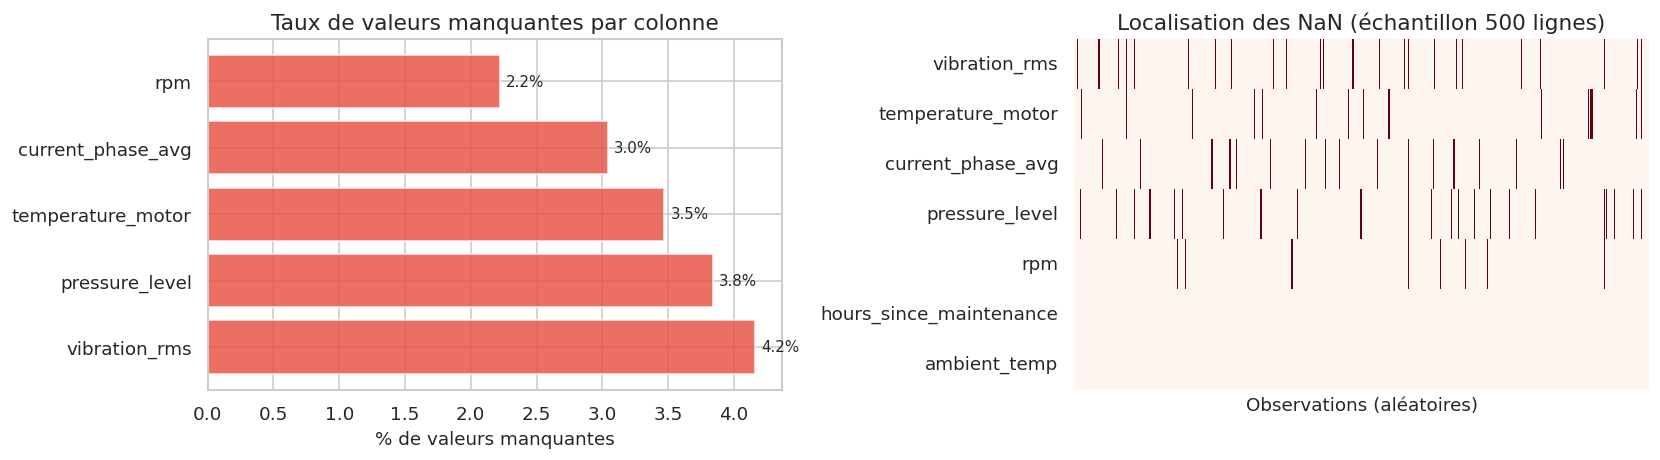

In [ ]:
# ─── Heatmap des valeurs manquantes ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Barplot
ax = axes[0]
bars = ax.barh(missing_df.index, missing_df['pct'], color='#e74c3c', alpha=0.8)
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de valeurs manquantes par colonne')
for bar, pct in zip(bars, missing_df['pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

# Heatmap sur un échantillon
ax2 = axes[1]
sample_null = df[FEATURES_NUM].isnull().astype(int)
sns.heatmap(
    sample_null.sample(500, random_state=42).T,
    ax=ax2, cmap='Reds', cbar=False,
    xticklabels=False, yticklabels=True
)
ax2.set_title('Localisation des NaN (échantillon 500 lignes)')
ax2.set_xlabel('Observations (aléatoires)')

plt.tight_layout()
plt.show()

In [ ]:
# ─── Doublons ─────────────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
n_dup_ts = df.duplicated(subset=['timestamp', 'machine_id']).sum()
print(f"Doublons complets          : {n_dup}")
print(f"Doublons (timestamp+machine): {n_dup_ts}")

# Analyse des NaN par rapport à la cible
print("\n── NaN selon failure_within_24h ──")
for col in FEATURES_NUM:
    rate_0 = df[df['failure_within_24h']==0][col].isnull().mean() * 100
    rate_1 = df[df['failure_within_24h']==1][col].isnull().mean() * 100
    if rate_0 > 0 or rate_1 > 0:
        print(f"  {col:<28} | Normal: {rate_0:.1f}%  | Panne: {rate_1:.1f}%")

Doublons complets          : 0
Doublons (timestamp+machine): 0

── NaN selon failure_within_24h ──
  vibration_rms                | Normal: 4.2%  | Panne: 3.8%
  temperature_motor            | Normal: 3.5%  | Panne: 3.5%
  current_phase_avg            | Normal: 3.0%  | Panne: 3.3%
  pressure_level               | Normal: 3.9%  | Panne: 3.7%
  rpm                          | Normal: 2.2%  | Panne: 2.1%


<a id='3'></a>
## 3. Analyse univariée — Variables numériques

In [ ]:
# ─── Statistiques descriptives enrichies ──────────────────────────────────────
stats = df[FEATURES_NUM].describe().T
stats['cv'] = (stats['std'] / stats['mean'] * 100).round(1)  # Coefficient de variation
stats['skewness'] = df[FEATURES_NUM].skew().round(3)
stats['kurtosis'] = df[FEATURES_NUM].kurt().round(3)
stats.style.background_gradient(subset=['std', 'cv'], cmap='YlOrRd').format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max,cv,skewness,kurtosis
vibration_rms,23042.00,1.62,1.08,0.35,0.82,1.27,2.27,10.00,66.60,1.48,3.87
temperature_motor,23208.00,51.40,12.52,28.00,42.61,50.06,59.96,95.00,24.40,0.50,0.14
current_phase_avg,23311.00,8.82,5.37,2.20,4.63,6.43,13.12,35.00,60.80,0.84,0.25
pressure_level,23118.00,59.01,38.72,10.10,22.70,46.30,94.70,206.50,65.60,0.67,-0.64
rpm,23509.00,1144.85,912.67,124.10,489.40,856.00,1676.00,4098.80,79.70,1.11,0.39
hours_since_maintenance,24042.00,172.63,150.72,0.00,42.87,121.61,295.57,575.63,87.30,0.73,-0.70
ambient_temp,24042.00,13.00,2.88,8.00,10.50,13.00,15.50,18.00,22.20,0.00,-1.19


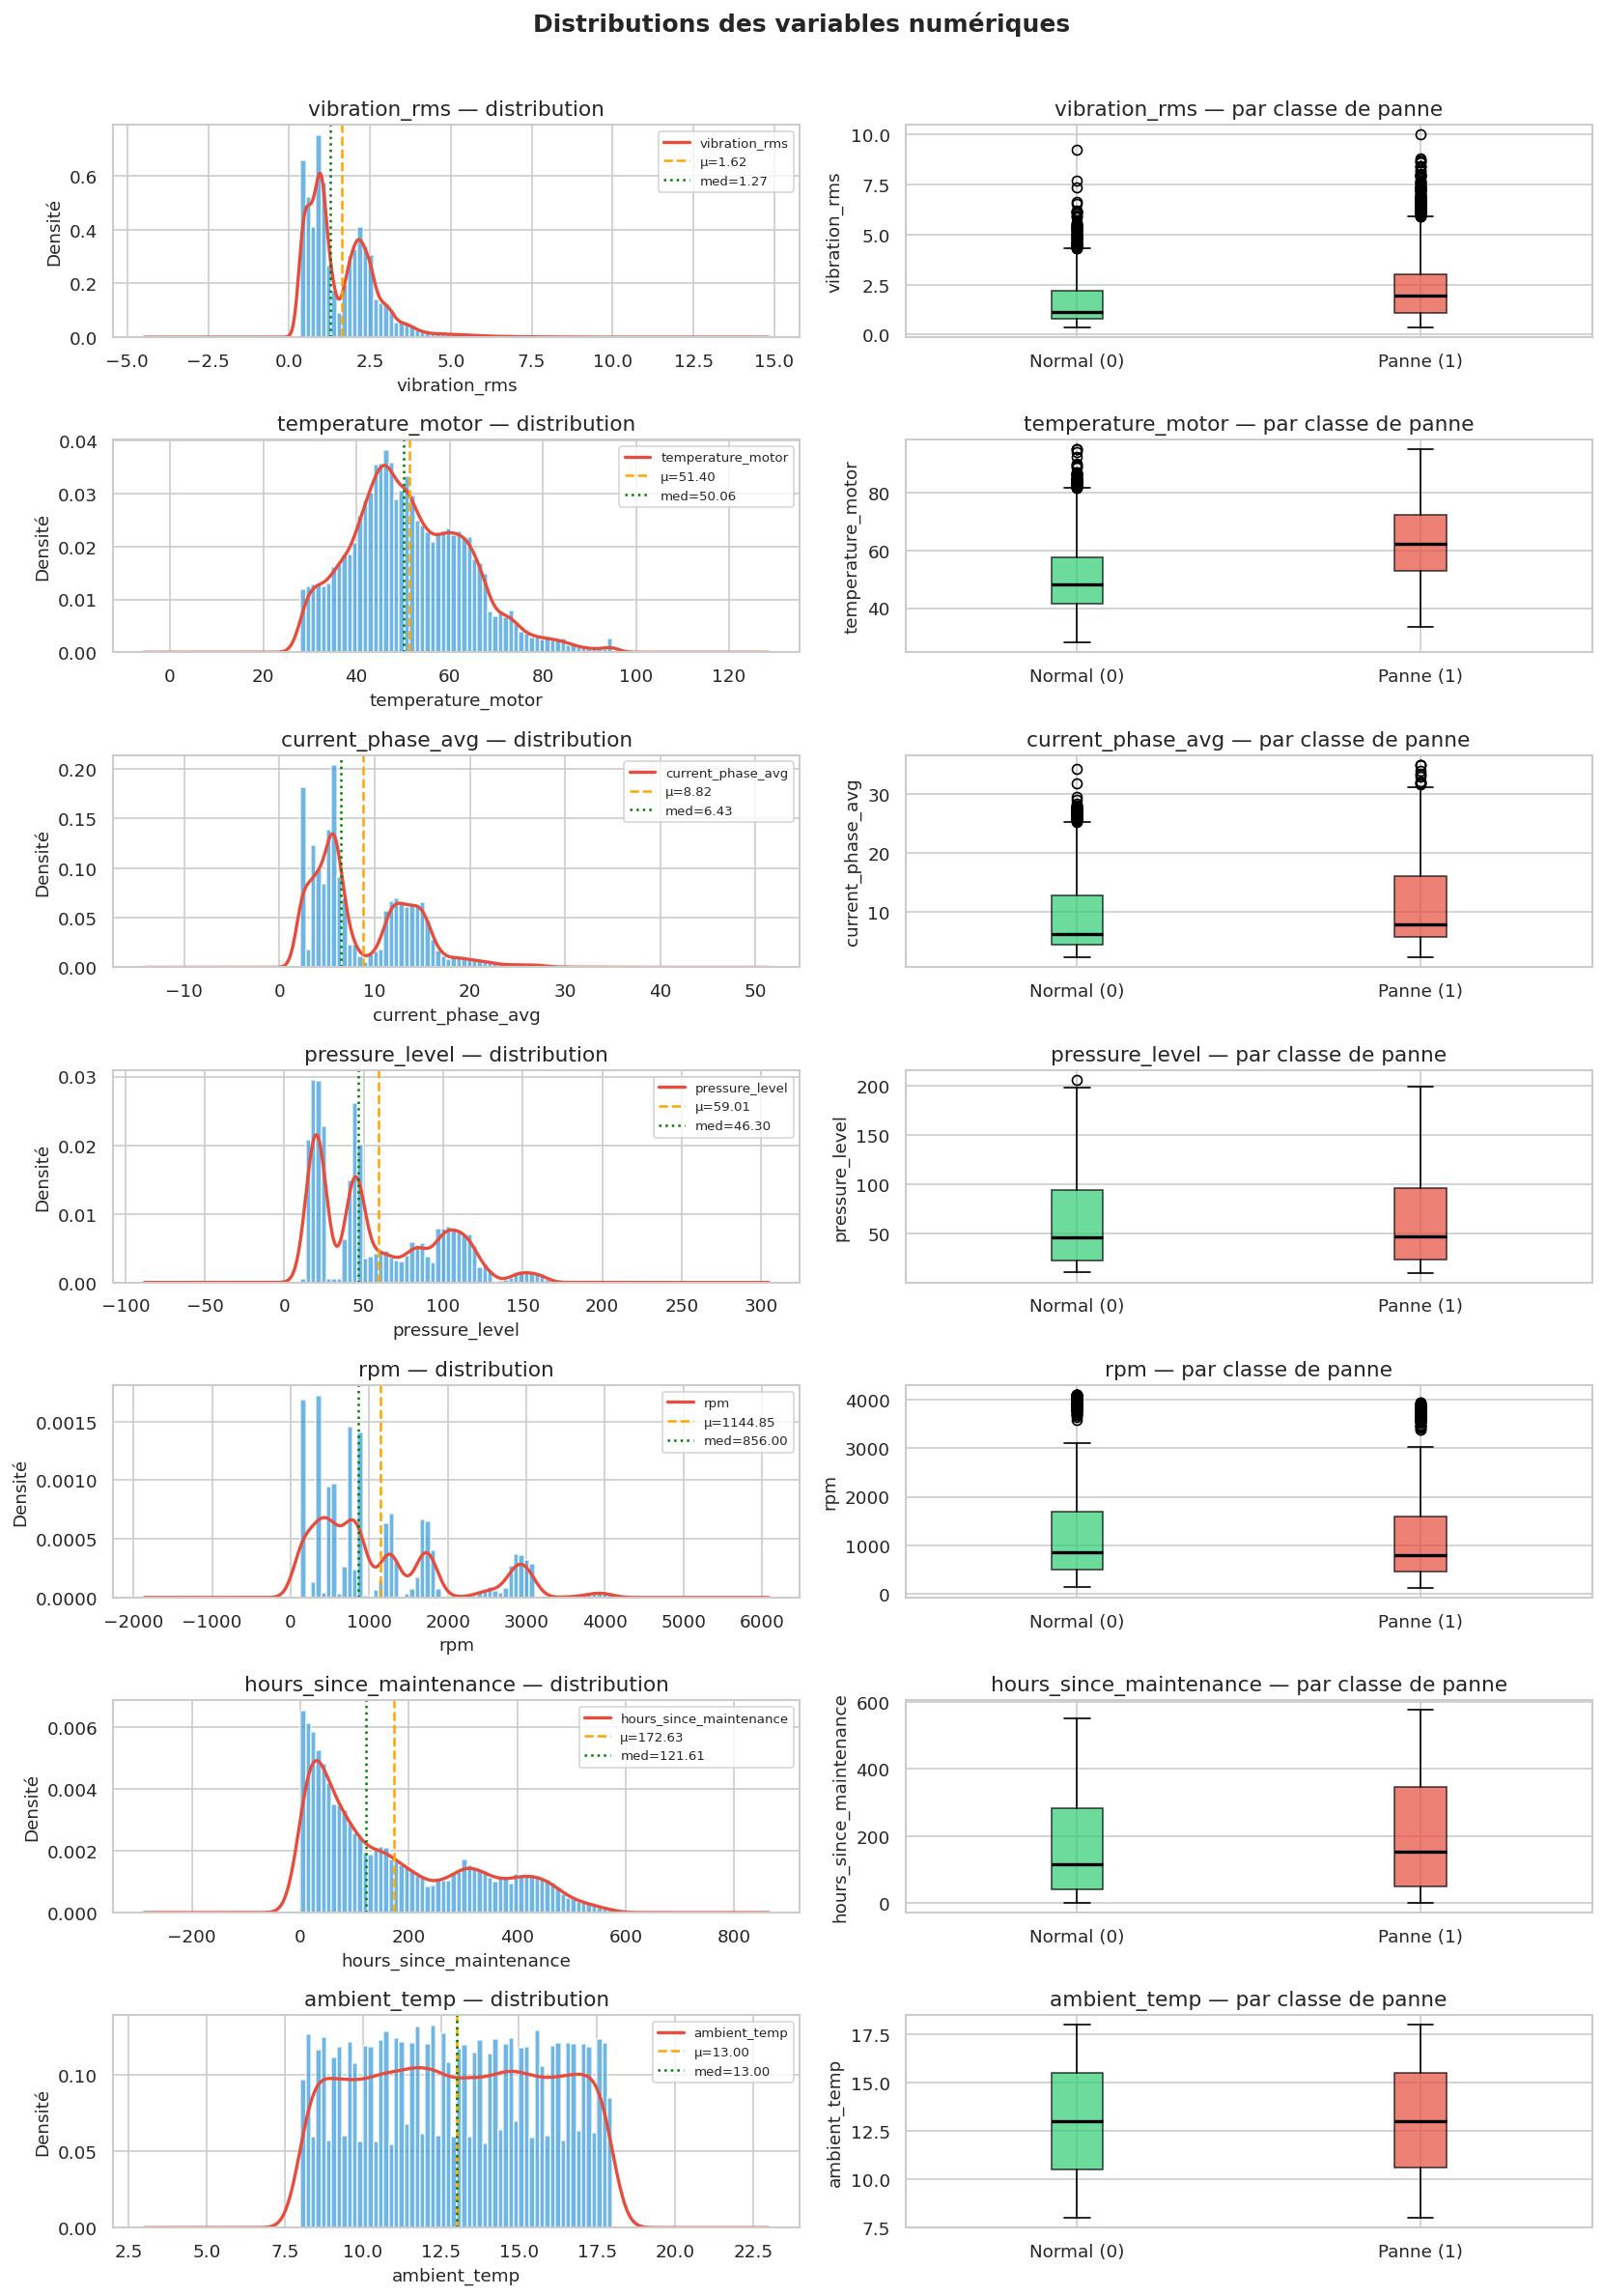

In [ ]:
# ─── Distributions + Boxplots pour toutes les variables numériques ────────────
fig, axes = plt.subplots(len(FEATURES_NUM), 2, figsize=(14, len(FEATURES_NUM) * 2.8))
fig.suptitle('Distributions des variables numériques', fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(FEATURES_NUM):
    data = df[col].dropna()

    # Histogramme + KDE
    ax1 = axes[i, 0]
    ax1.hist(data, bins=60, color='#3498db', alpha=0.7, edgecolor='white', density=True)
    data.plot(kind='kde', ax=ax1, color='#e74c3c', linewidth=2)
    ax1.set_title(f'{col} — distribution')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Densité')
    # Annotations statistiques
    ax1.axvline(data.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.2f}')
    ax1.axvline(data.median(), color='green', linestyle=':', linewidth=1.5, label=f'med={data.median():.2f}')
    ax1.legend(fontsize=8)

    # Boxplot splitté par failure_within_24h
    ax2 = axes[i, 1]
    data_by_class = [df[df['failure_within_24h']==0][col].dropna(),
                     df[df['failure_within_24h']==1][col].dropna()]
    bp = ax2.boxplot(data_by_class, labels=['Normal (0)', 'Panne (1)'], patch_artist=True,
                     boxprops=dict(alpha=0.7), medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE_BINARY):
        patch.set_facecolor(color)
    ax2.set_title(f'{col} — par classe de panne')
    ax2.set_ylabel(col)

plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Analyse univariée — Variables catégorielles

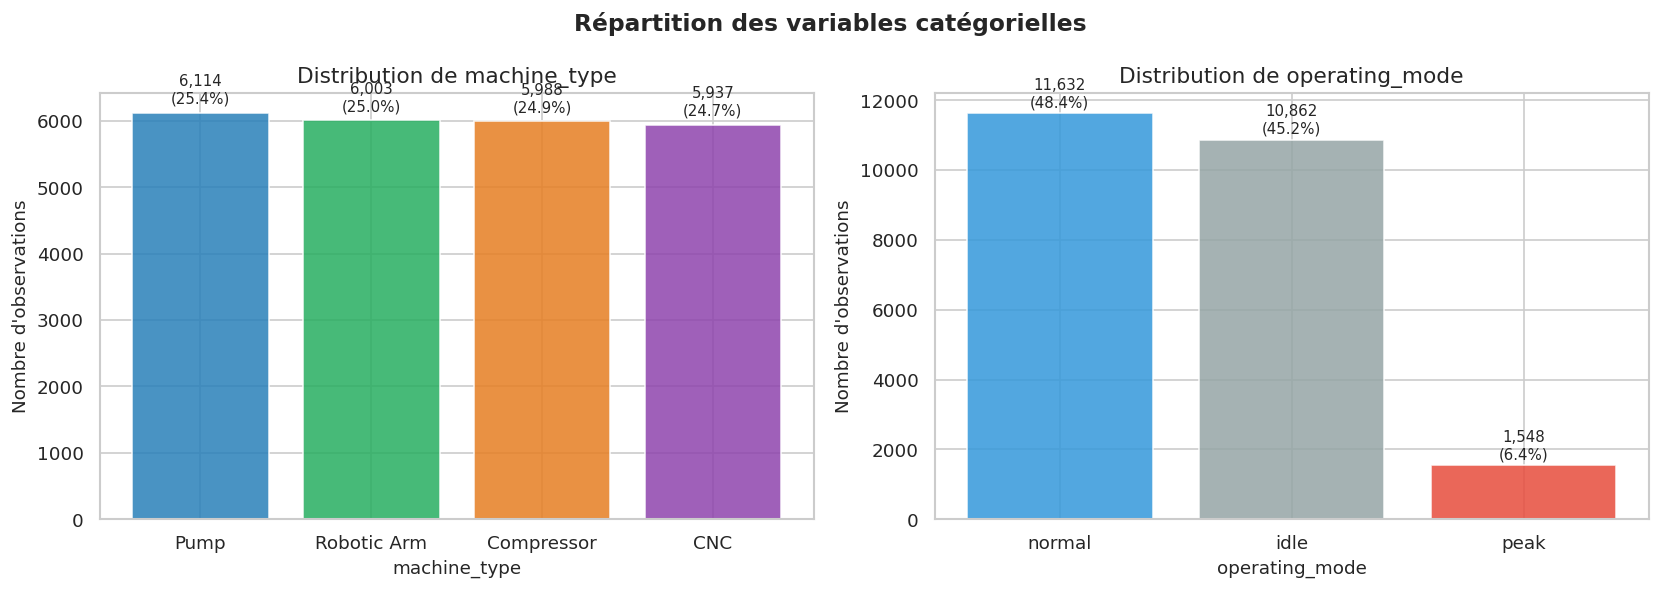

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Répartition des variables catégorielles', fontsize=14, fontweight='bold')

for ax, col, palette in zip(axes, FEATURES_CAT, [PALETTE_MACHINE, ['#3498db', '#95a5a6', '#e74c3c']]):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=palette[:len(counts)], alpha=0.85, edgecolor='white')
    ax.set_title(f'Distribution de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre d\'observations')
    for bar, count in zip(bars, counts.values):
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. Analyse de la variable cible principale : `failure_within_24h`

In [ ]:
# ─── Déséquilibre des classes ─────────────────────────────────────────────────
vc = df['failure_within_24h'].value_counts()
vc_pct = df['failure_within_24h'].value_counts(normalize=True) * 100

print("=" * 45)
print("  Distribution de failure_within_24h")
print("=" * 45)
for cls, count in vc.items():
    label = 'Normal (pas de panne)' if cls == 0 else 'Panne imminente (<24h)'
    bar = '█' * int(vc_pct[cls] / 2)
    print(f"  Classe {cls} [{label}]")
    print(f"    {bar} {count:,} ({vc_pct[cls]:.1f}%)")
    print()

ratio = vc[0] / vc[1]
print(f"⚠️  Ratio déséquilibre : {ratio:.1f}:1  (classe majoritaire / minoritaire)")
print(f"   → Stratégies recommandées : class_weight='balanced', SMOTE, stratified split")

  Distribution de failure_within_24h
  Classe 0 [Normal (pas de panne)]
    ██████████████████████████████████████████ 20,482 (85.2%)

  Classe 1 [Panne imminente (<24h)]
    ███████ 3,560 (14.8%)

⚠️  Ratio déséquilibre : 5.8:1  (classe majoritaire / minoritaire)
   → Stratégies recommandées : class_weight='balanced', SMOTE, stratified split


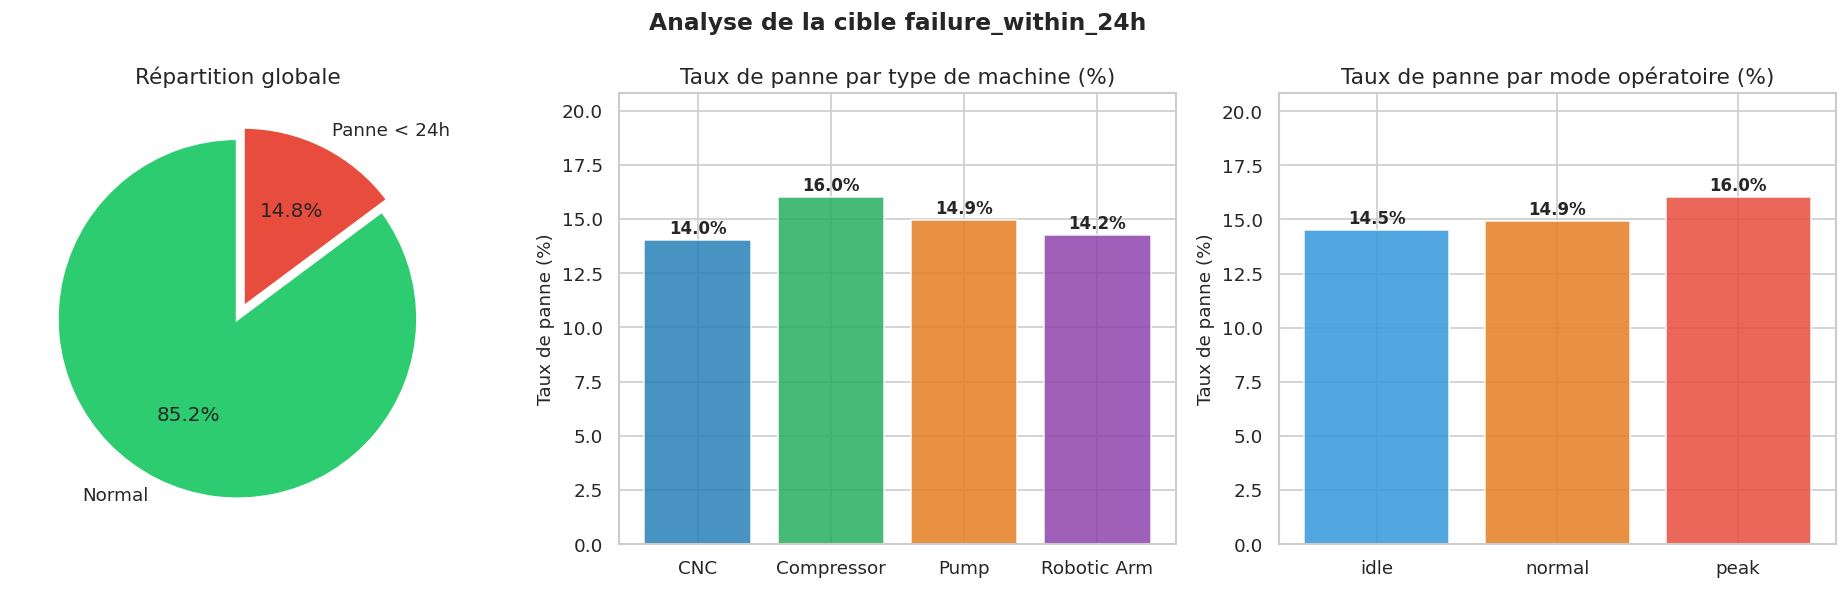

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analyse de la cible failure_within_24h', fontsize=14, fontweight='bold')

# Camembert
axes[0].pie(vc.values, labels=['Normal', 'Panne < 24h'],
            colors=PALETTE_BINARY, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.07),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Répartition globale')

# Taux de panne par type de machine
rate_machine = df.groupby('machine_type')['failure_within_24h'].mean() * 100
bars = axes[1].bar(rate_machine.index, rate_machine.values,
                   color=PALETTE_MACHINE, alpha=0.85, edgecolor='white')
axes[1].set_title('Taux de panne par type de machine (%)')
axes[1].set_ylabel('Taux de panne (%)')
axes[1].set_ylim(0, rate_machine.max() * 1.3)
for bar, val in zip(bars, rate_machine.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Taux de panne par mode opératoire
rate_mode = df.groupby('operating_mode')['failure_within_24h'].mean() * 100
bars2 = axes[2].bar(rate_mode.index, rate_mode.values,
                    color=['#3498db', '#e67e22', '#e74c3c'], alpha=0.85, edgecolor='white')
axes[2].set_title('Taux de panne par mode opératoire (%)')
axes[2].set_ylabel('Taux de panne (%)')
axes[2].set_ylim(0, rate_mode.max() * 1.3)
for bar, val in zip(bars2, rate_mode.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Analyse des variables cibles secondaires

In [ ]:
# ─── failure_type ─────────────────────────────────────────────────────────────
ft_counts = df['failure_type'].value_counts()
print("── Répartition de failure_type ──")
for ft, cnt in ft_counts.items():
    bar = '█' * int(cnt / 100)
    print(f"  {ft:<20} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)  {bar}")

── Répartition de failure_type ──
  none                 20,482  (85.2%)  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  bearing               1,117  (4.6%)  ███████████
  motor_overheat        1,060  (4.4%)  ██████████
  hydraulic               728  (3.0%)  ███████
  electrical              655  (2.7%)  ██████


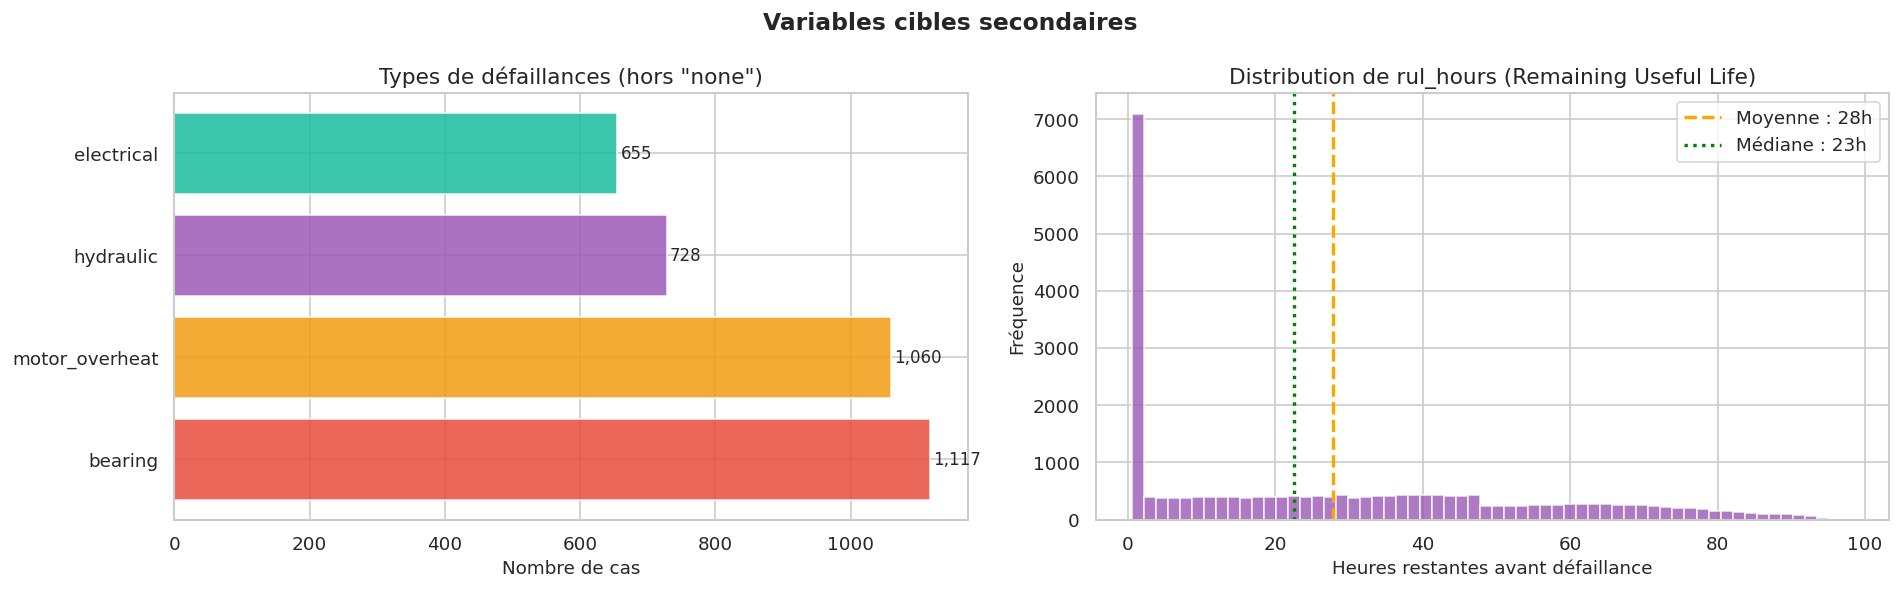

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Variables cibles secondaires', fontsize=14, fontweight='bold')

# failure_type sans 'none'
ft_no_none = ft_counts.drop('none')
axes[0].barh(ft_no_none.index, ft_no_none.values,
             color=PALETTE_TYPES[1:], alpha=0.85, edgecolor='white')
axes[0].set_title('Types de défaillances (hors "none")')
axes[0].set_xlabel('Nombre de cas')
for i, (idx, val) in enumerate(ft_no_none.items()):
    axes[0].text(val + 5, i, f'{val:,}', va='center', fontsize=10)

# rul_hours — distribution
axes[1].hist(df['rul_hours'], bins=60, color='#9b59b6', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribution de rul_hours (Remaining Useful Life)')
axes[1].set_xlabel('Heures restantes avant défaillance')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(df['rul_hours'].mean(), color='orange', linestyle='--',
                linewidth=2, label=f"Moyenne : {df['rul_hours'].mean():.0f}h")
axes[1].axvline(df['rul_hours'].median(), color='green', linestyle=':',
                linewidth=2, label=f"Médiane : {df['rul_hours'].median():.0f}h")
axes[1].legend()

plt.tight_layout()
plt.show()

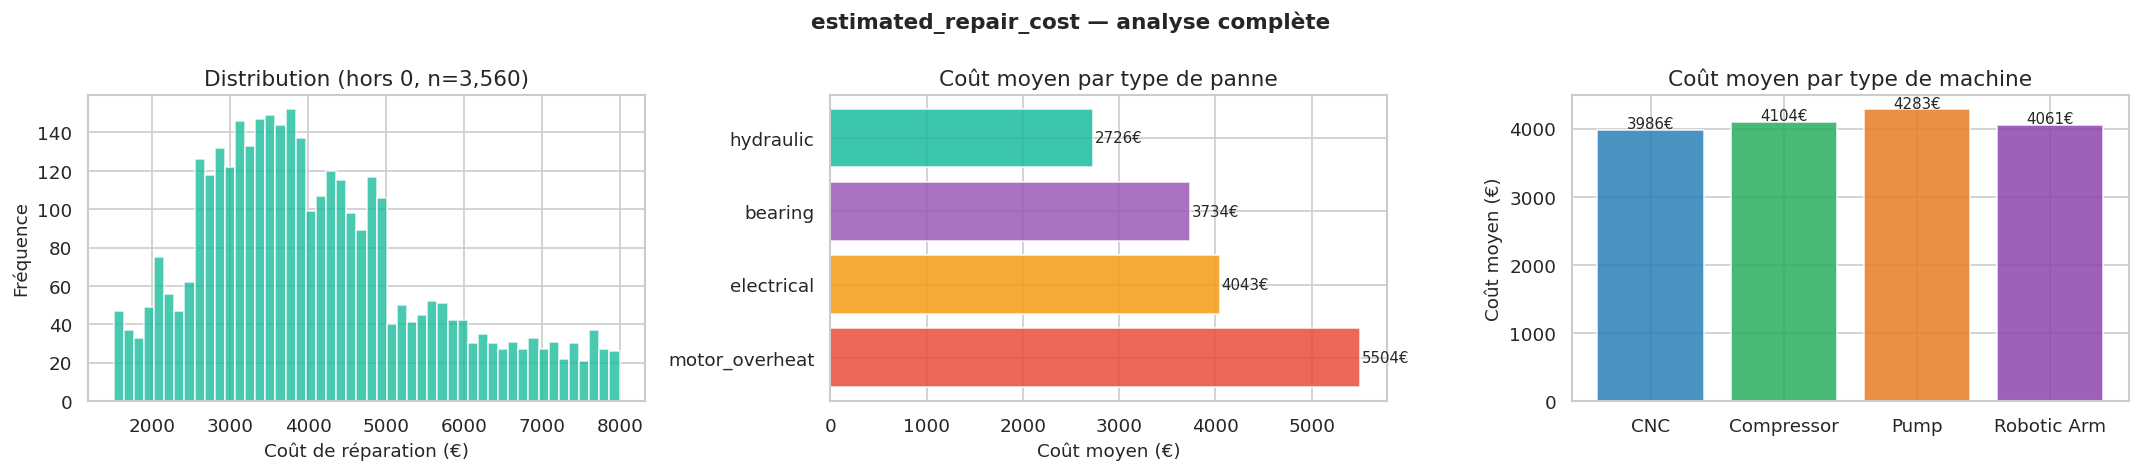

In [ ]:
# ─── estimated_repair_cost ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('estimated_repair_cost — analyse complète', fontsize=13, fontweight='bold')

# Distribution globale (sans les 0)
cost_nonzero = df[df['estimated_repair_cost'] > 0]['estimated_repair_cost']
axes[0].hist(cost_nonzero, bins=50, color='#1abc9c', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Distribution (hors 0, n={len(cost_nonzero):,})')
axes[0].set_xlabel('Coût de réparation (€)')
axes[0].set_ylabel('Fréquence')

# Par type de panne
cost_by_type = df[df['failure_type'] != 'none'].groupby('failure_type')['estimated_repair_cost'].mean().sort_values(ascending=False)
axes[1].barh(cost_by_type.index, cost_by_type.values,
             color=PALETTE_TYPES[1:len(cost_by_type)+1], alpha=0.85)
axes[1].set_title('Coût moyen par type de panne')
axes[1].set_xlabel('Coût moyen (€)')
for i, (idx, val) in enumerate(cost_by_type.items()):
    axes[1].text(val + 20, i, f'{val:.0f}€', va='center', fontsize=9)

# Par type de machine
cost_by_machine = df[df['estimated_repair_cost'] > 0].groupby('machine_type')['estimated_repair_cost'].mean()
axes[2].bar(cost_by_machine.index, cost_by_machine.values,
            color=PALETTE_MACHINE, alpha=0.85, edgecolor='white')
axes[2].set_title('Coût moyen par type de machine')
axes[2].set_ylabel('Coût moyen (€)')
for i, (idx, val) in enumerate(cost_by_machine.items()):
    axes[2].text(i, val + 20, f'{val:.0f}€', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Analyse bivariée — Corrélations

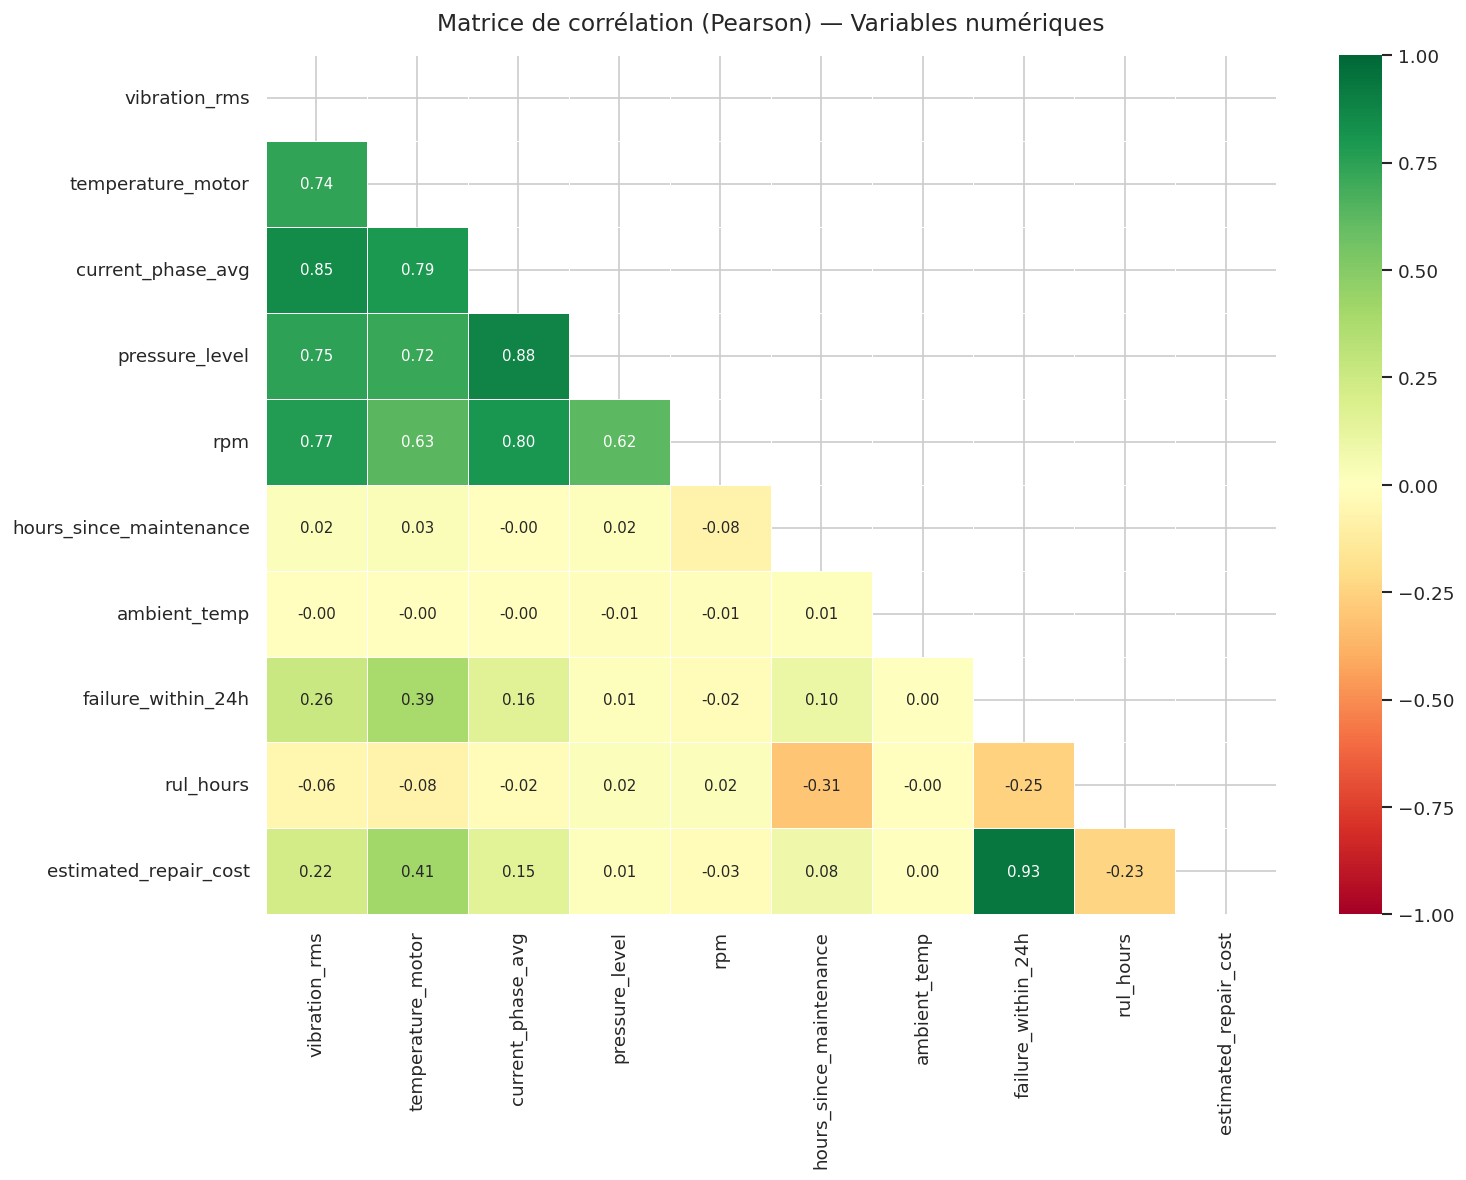


── Corrélations avec failure_within_24h (triées) ──
  estimated_repair_cost        +0.932  ██████████████████
  temperature_motor            +0.386  ███████
  vibration_rms                +0.264  █████
  rul_hours                    -0.253  █████
  current_phase_avg            +0.157  ███
  hours_since_maintenance      +0.100  █
  rpm                          -0.024  
  pressure_level               +0.013  
  ambient_temp                 +0.004  


In [ ]:
# ─── Matrice de corrélation ───────────────────────────────────────────────────
num_cols = FEATURES_NUM + ['failure_within_24h', 'rul_hours', 'estimated_repair_cost']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Masque triangle supérieur

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', ax=ax,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title('Matrice de corrélation (Pearson) — Variables numériques', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Corrélations avec failure_within_24h
print("\n── Corrélations avec failure_within_24h (triées) ──")
corr_target = corr['failure_within_24h'].drop('failure_within_24h').sort_values(key=abs, ascending=False)
for var, val in corr_target.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else '-'
    print(f"  {var:<28} {sign}{abs(val):.3f}  {bar}")

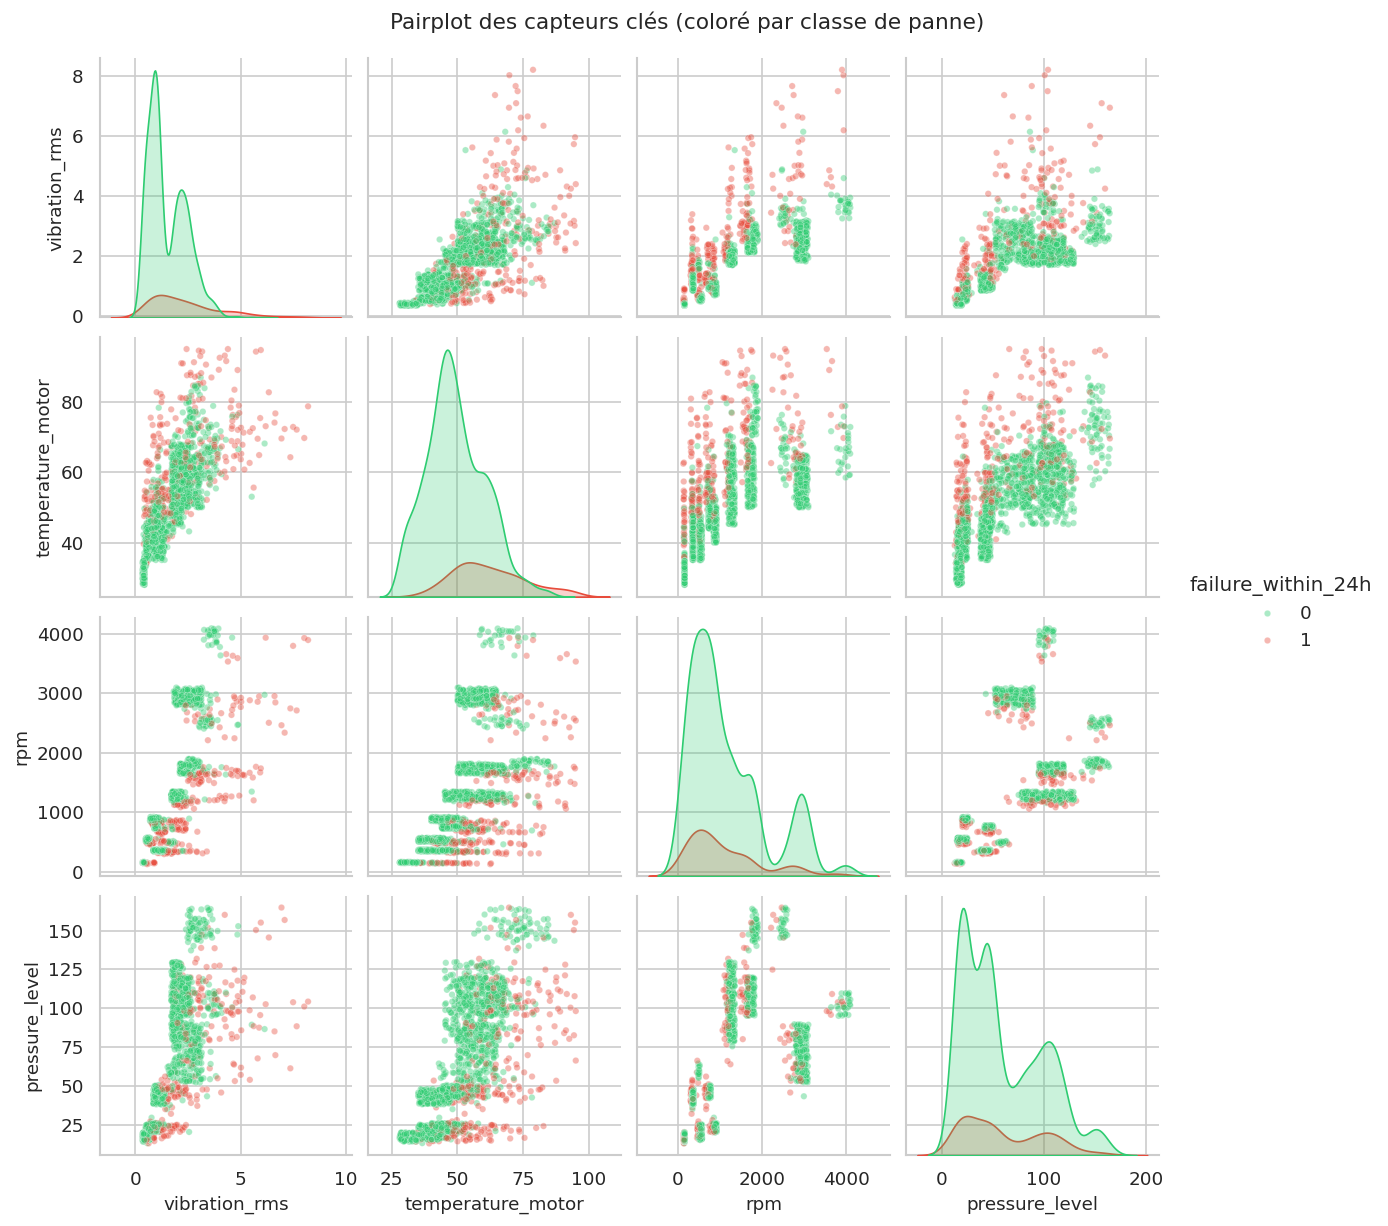

In [ ]:
# ─── Scatter matrix (pairplot) sur variables clés ─────────────────────────────
KEY_VARS = ['vibration_rms', 'temperature_motor', 'rpm', 'pressure_level', 'failure_within_24h']
df_sample = df[KEY_VARS].dropna().sample(2000, random_state=42)

g = sns.pairplot(
    df_sample, hue='failure_within_24h',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
    vars=['vibration_rms', 'temperature_motor', 'rpm', 'pressure_level']
)
g.figure.suptitle('Pairplot des capteurs clés (coloré par classe de panne)',
                  fontsize=13, y=1.02)
handles = g._legend_data
g.legend.set_title('failure_within_24h')
plt.show()

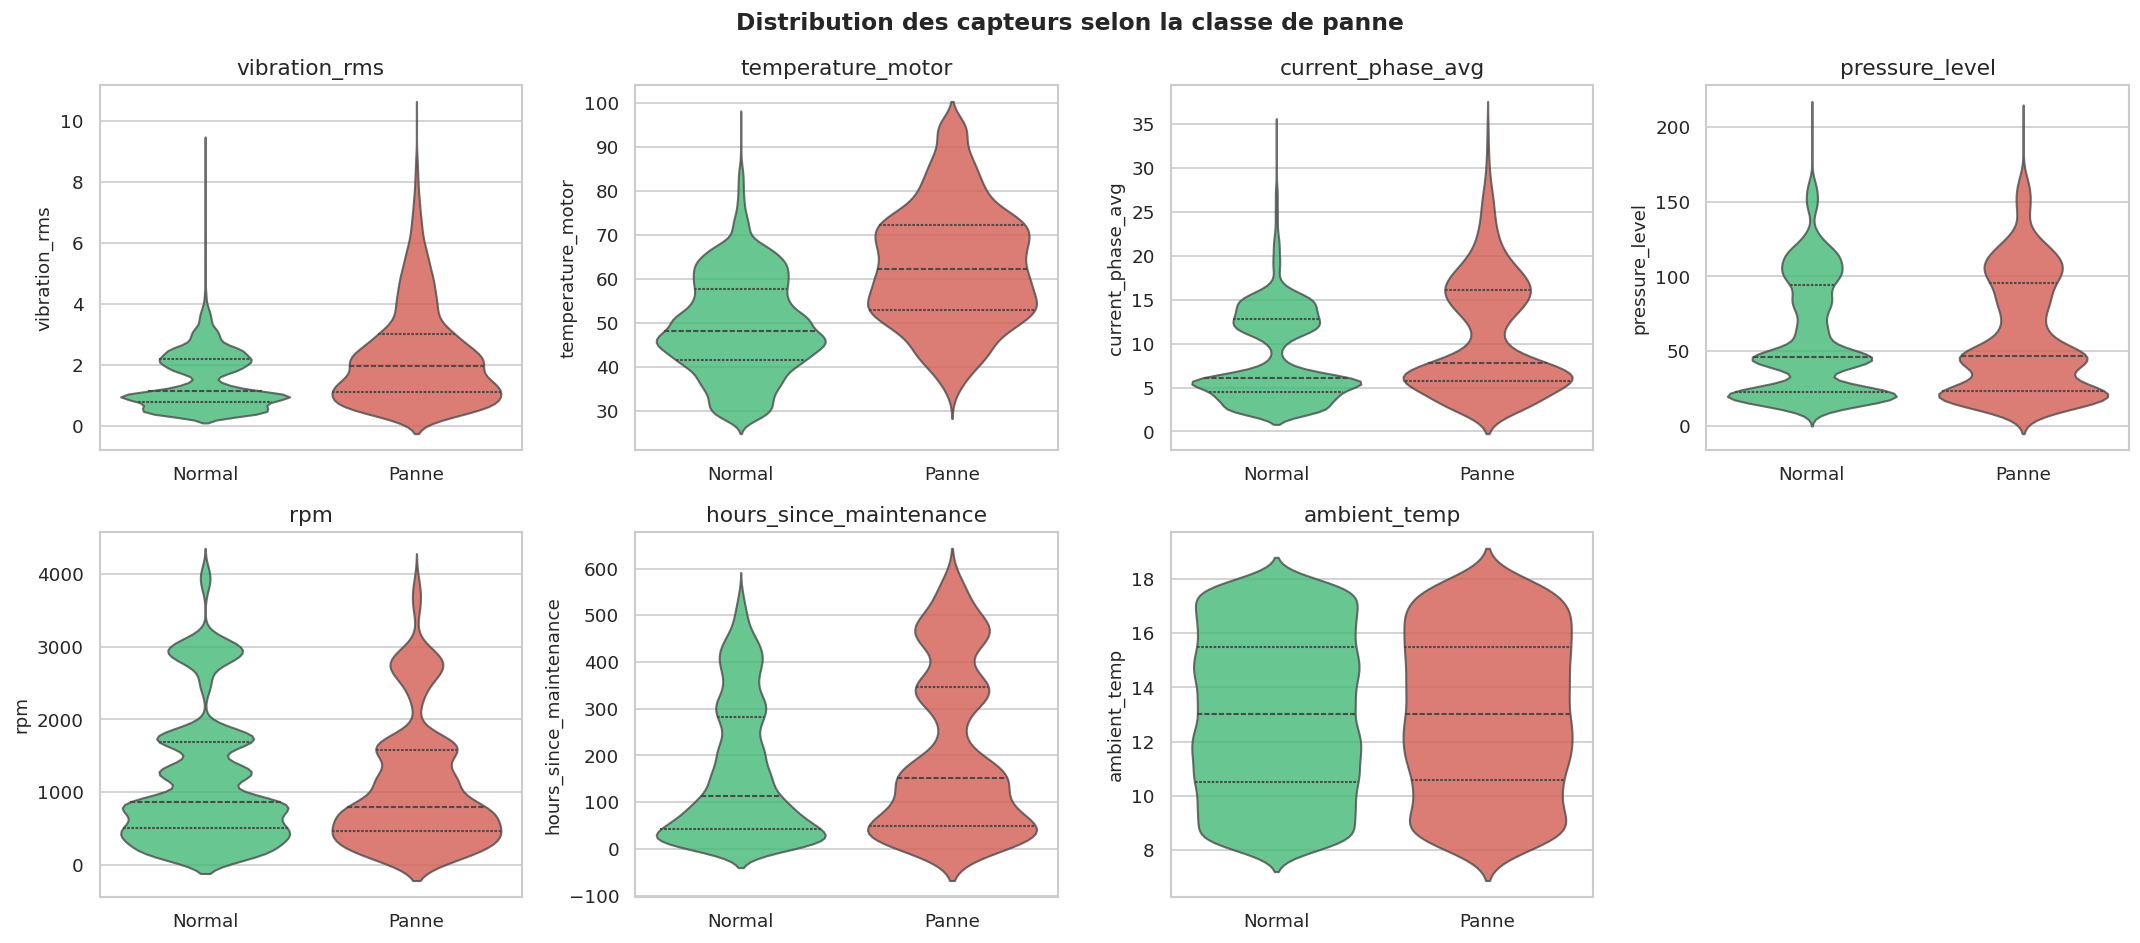

In [ ]:
# ─── Violinplots : distribution des capteurs par classe ───────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution des capteurs selon la classe de panne', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, FEATURES_NUM):
    data_plot = df[[col, 'failure_within_24h']].dropna()
    sns.violinplot(
        data=data_plot, x='failure_within_24h', y=col,
        palette=PALETTE_BINARY, ax=ax, inner='quartile', alpha=0.8
    )
    ax.set_xticklabels(['Normal', 'Panne'])
    ax.set_title(col)
    ax.set_xlabel('')

# Désactiver l'axe en trop
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. Analyse par machine_type & operating_mode

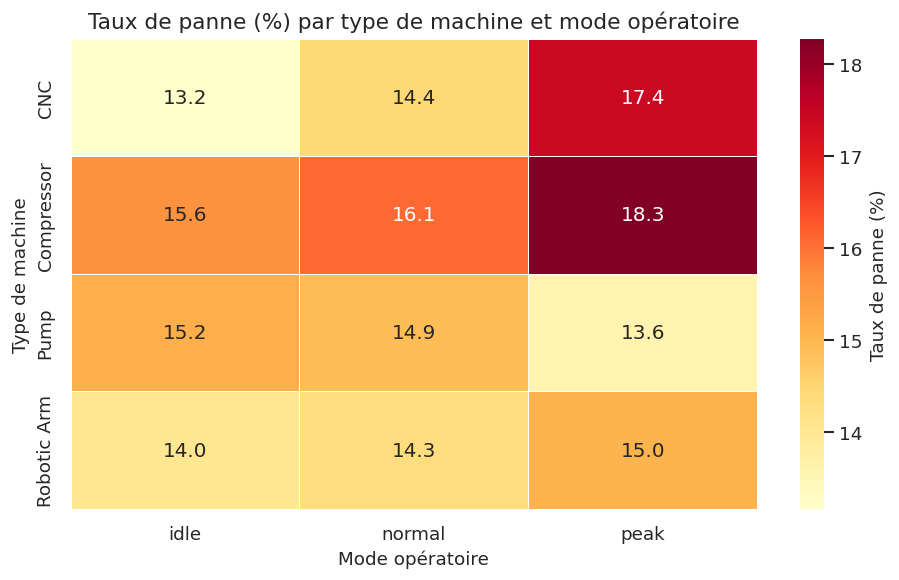

In [ ]:
# ─── Heatmap taux de panne × machine_type × operating_mode ──────────────────
pivot = df.groupby(['machine_type', 'operating_mode'])['failure_within_24h'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Taux de panne (%)'})
ax.set_title('Taux de panne (%) par type de machine et mode opératoire', fontsize=13)
ax.set_xlabel('Mode opératoire')
ax.set_ylabel('Type de machine')
plt.tight_layout()
plt.show()

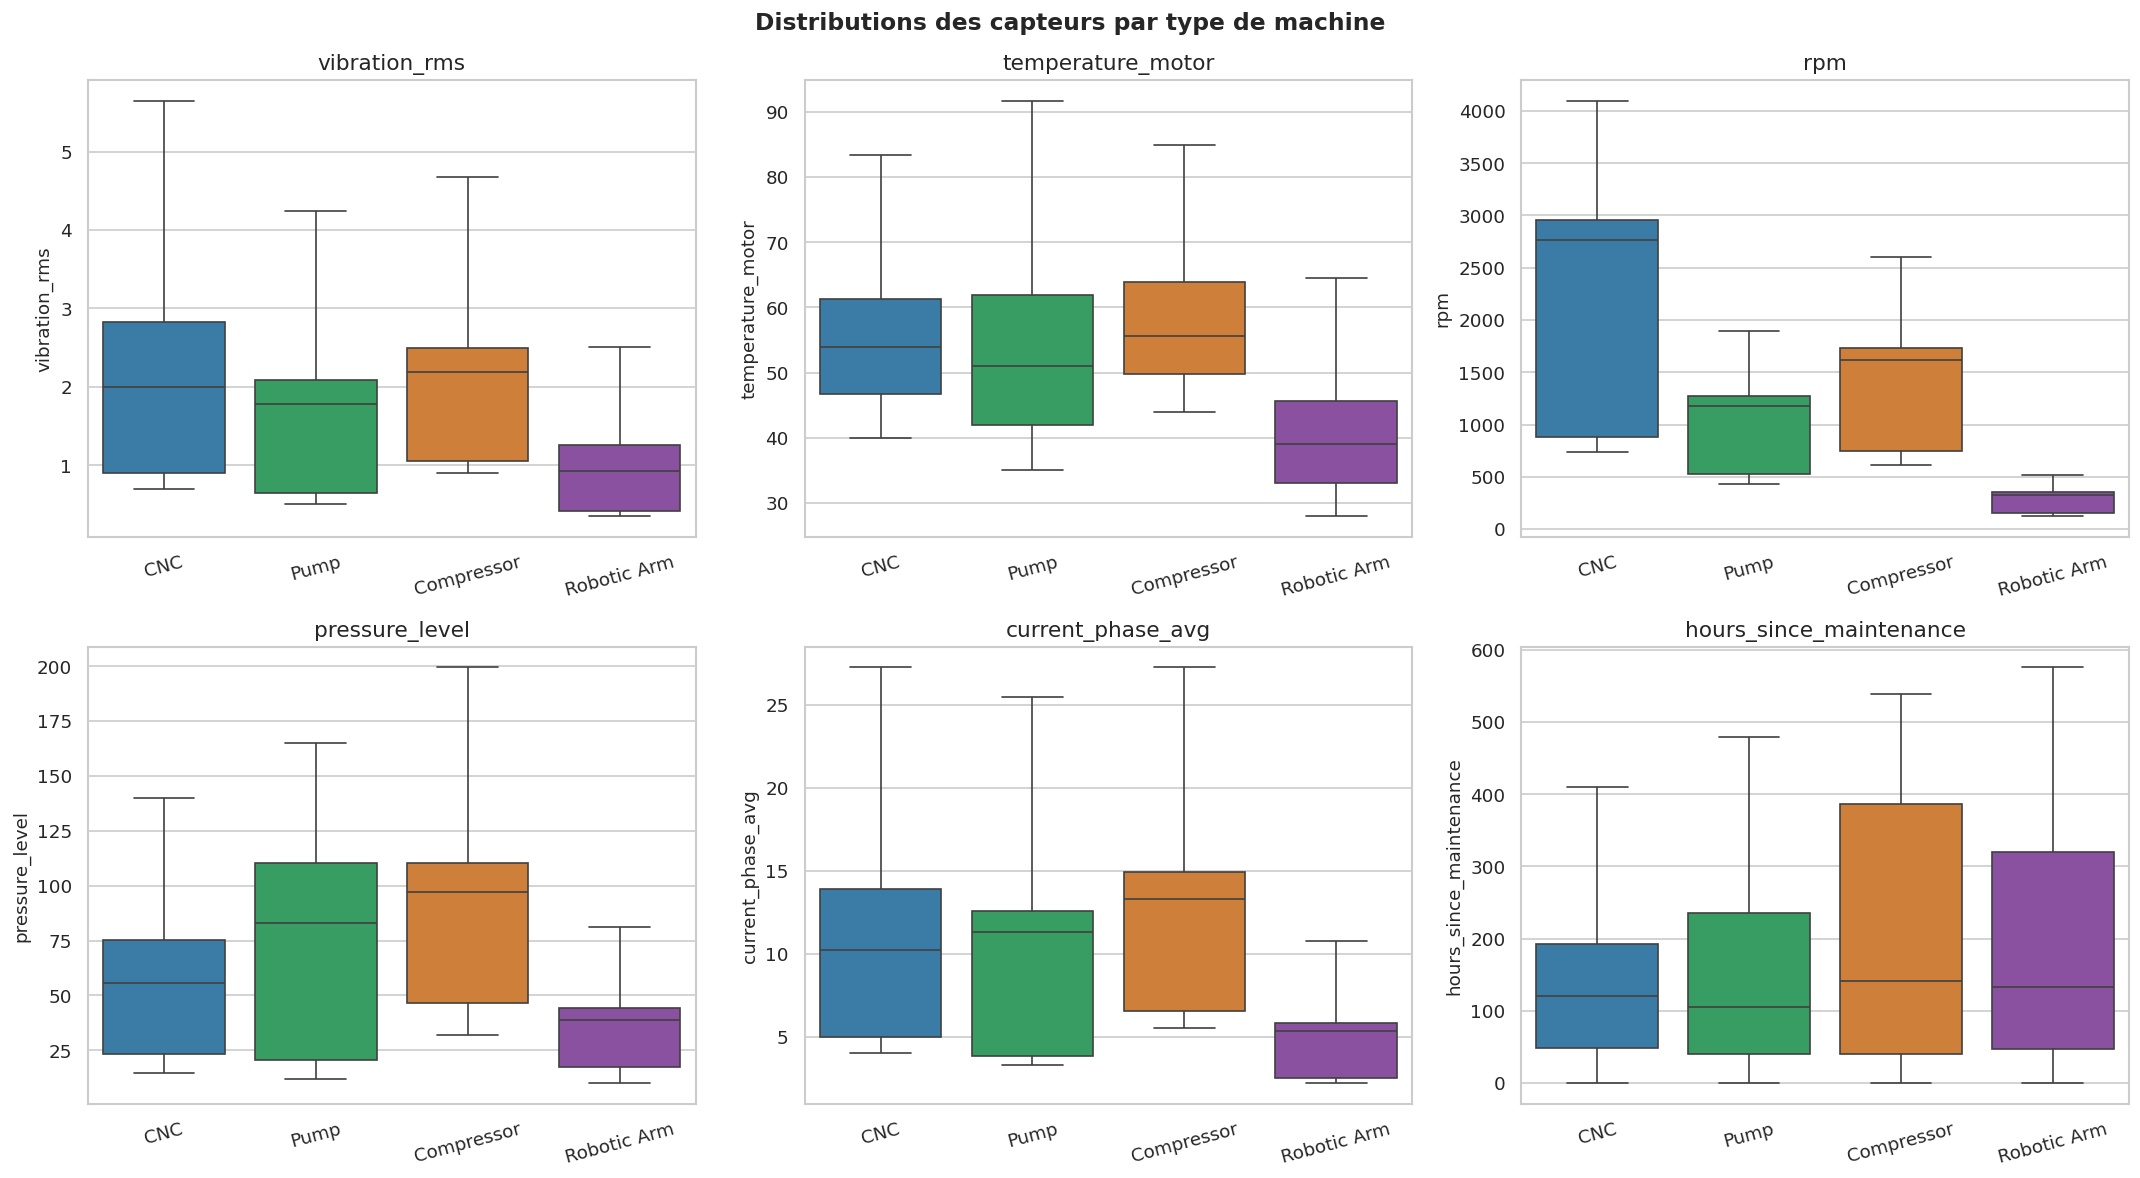

In [ ]:
# ─── Statistiques des capteurs par machine_type ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions des capteurs par type de machine', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, ['vibration_rms', 'temperature_motor',
                                'rpm', 'pressure_level',
                                'current_phase_avg', 'hours_since_maintenance']):
    data_plot = df[[col, 'machine_type']].dropna()
    sns.boxplot(
        data=data_plot, x='machine_type', y=col,
        palette=PALETTE_MACHINE, ax=ax, showfliers=False
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

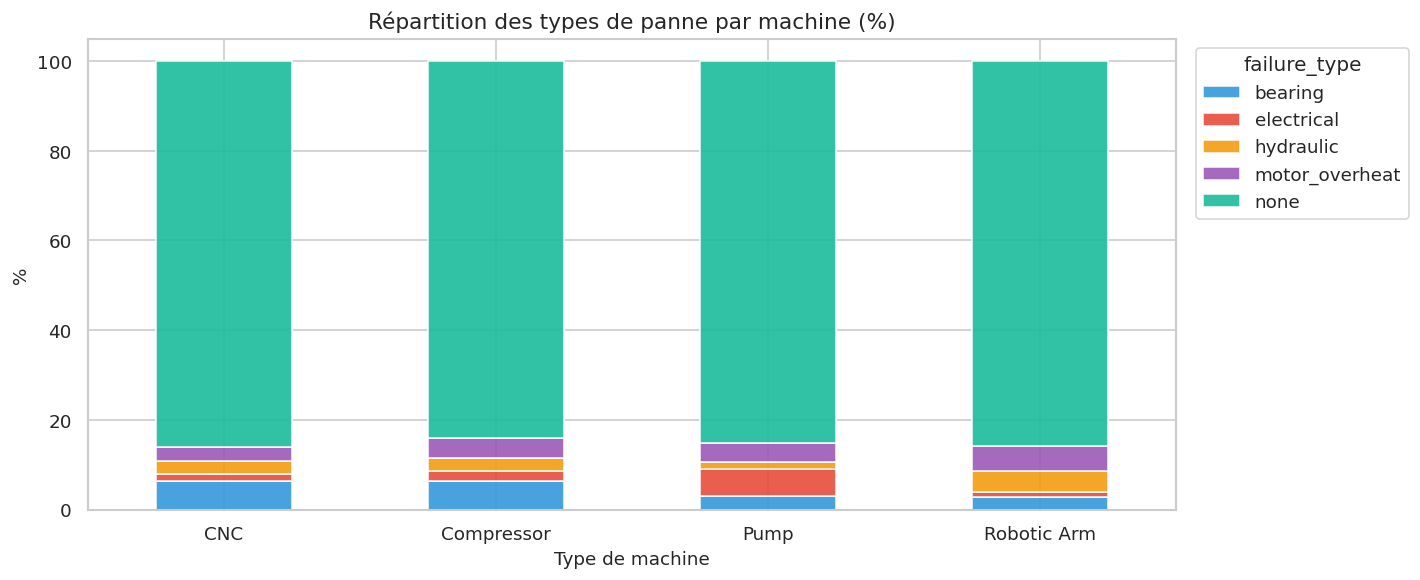

In [ ]:
# ─── Stacked barplot : failure_type par machine_type ──────────────────────────
ft_matrix = df.groupby(['machine_type', 'failure_type']).size().unstack(fill_value=0)
ft_pct = ft_matrix.div(ft_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ft_pct.plot(kind='bar', stacked=True, ax=ax,
            color=PALETTE_TYPES[:len(ft_pct.columns)], alpha=0.9,
            edgecolor='white')
ax.set_title('Répartition des types de panne par machine (%)', fontsize=13)
ax.set_ylabel('%')
ax.set_xlabel('Type de machine')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='failure_type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Analyse temporelle

In [ ]:
# ─── Préparation des agrégats temporels ──────────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

daily = df.groupby('date').agg(
    n_obs=('machine_id', 'count'),
    n_failures=('failure_within_24h', 'sum'),
    mean_vibration=('vibration_rms', 'mean'),
    mean_temp=('temperature_motor', 'mean')
).reset_index()
daily['failure_rate'] = daily['n_failures'] / daily['n_obs'] * 100
daily['date'] = pd.to_datetime(daily['date'])

print(f"Plage temporelle : {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Nombre de jours : {len(daily)}")

Plage temporelle : 2024-01-01 → 2024-01-14
Nombre de jours : 14


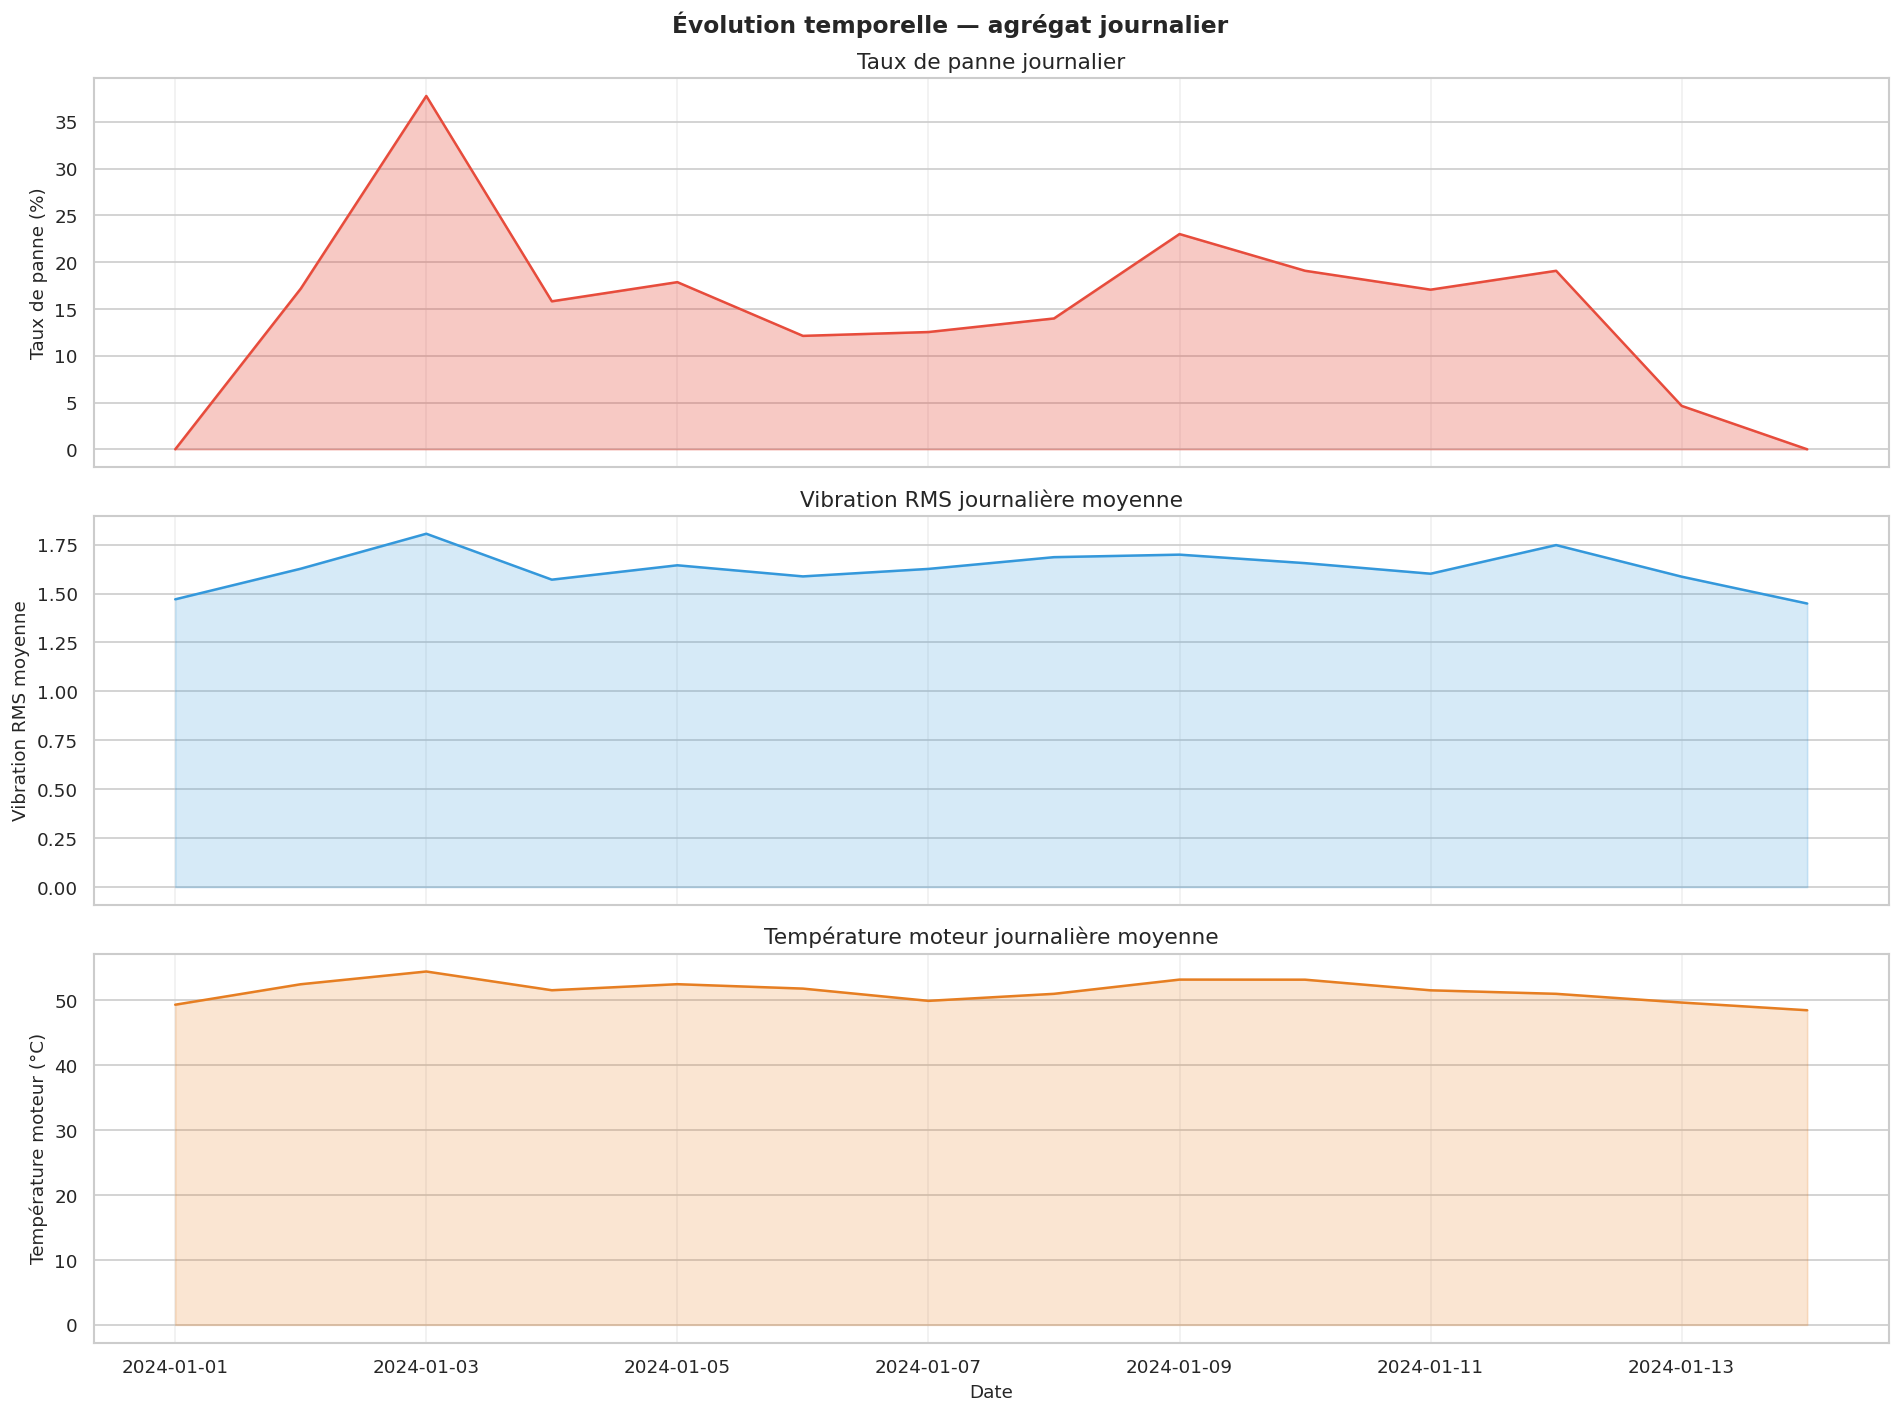

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Évolution temporelle — agrégat journalier', fontsize=14, fontweight='bold')

# Taux de panne journalier
axes[0].fill_between(daily['date'], daily['failure_rate'],
                     alpha=0.3, color='#e74c3c')
axes[0].plot(daily['date'], daily['failure_rate'],
             color='#e74c3c', linewidth=1.5)
axes[0].set_ylabel('Taux de panne (%)')
axes[0].set_title('Taux de panne journalier')

# Vibration moyenne
axes[1].plot(daily['date'], daily['mean_vibration'],
             color='#3498db', linewidth=1.5)
axes[1].fill_between(daily['date'], daily['mean_vibration'],
                     alpha=0.2, color='#3498db')
axes[1].set_ylabel('Vibration RMS moyenne')
axes[1].set_title('Vibration RMS journalière moyenne')

# Température moyenne
axes[2].plot(daily['date'], daily['mean_temp'],
             color='#e67e22', linewidth=1.5)
axes[2].fill_between(daily['date'], daily['mean_temp'],
                     alpha=0.2, color='#e67e22')
axes[2].set_ylabel('Température moteur (°C)')
axes[2].set_title('Température moteur journalière moyenne')
axes[2].set_xlabel('Date')

for ax in axes:
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

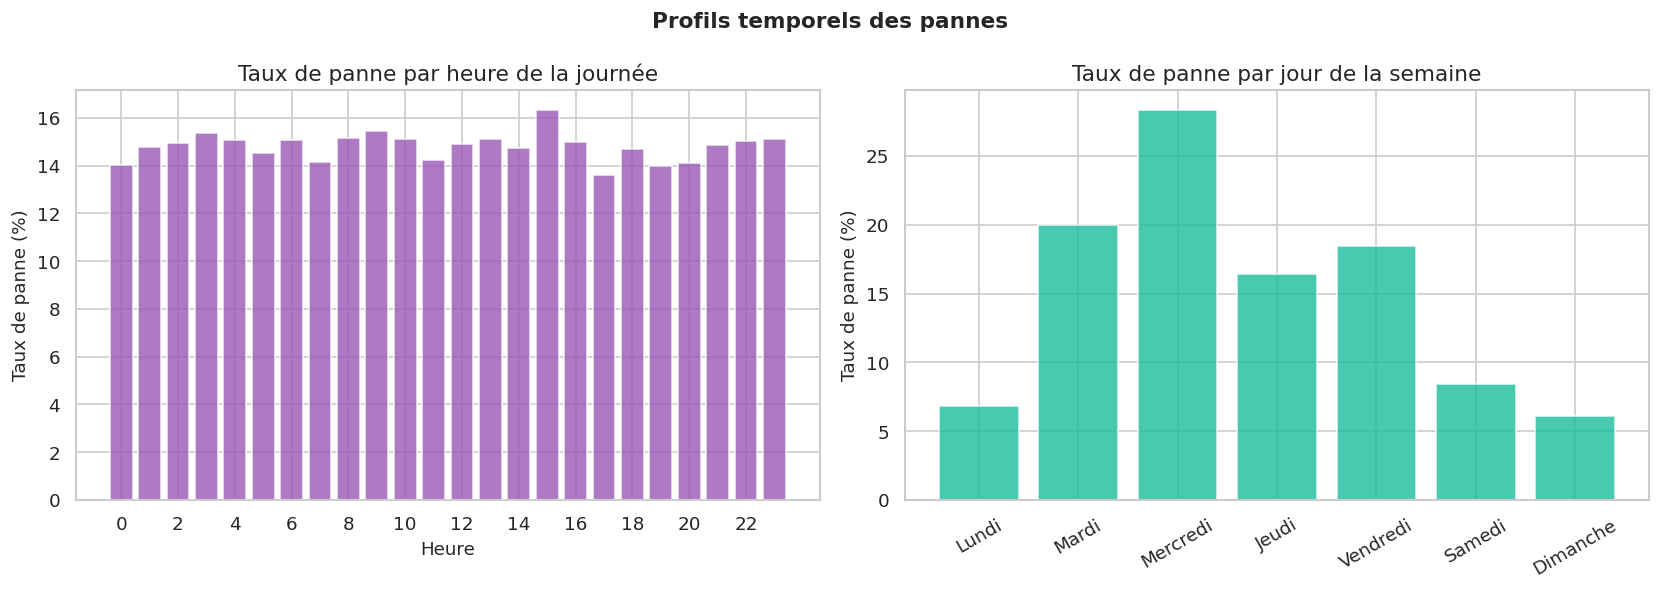

In [ ]:
# ─── Profil horaire des pannes ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profils temporels des pannes', fontsize=13, fontweight='bold')

# Par heure
hourly_rate = df.groupby('hour')['failure_within_24h'].mean() * 100
axes[0].bar(hourly_rate.index, hourly_rate.values,
            color='#9b59b6', alpha=0.8, edgecolor='white')
axes[0].set_title('Taux de panne par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Taux de panne (%)')
axes[0].set_xticks(range(0, 24, 2))

# Par jour de la semaine
day_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
daily_rate = df.groupby('dayofweek')['failure_within_24h'].mean() * 100
axes[1].bar([day_labels[i] for i in daily_rate.index], daily_rate.values,
            color='#1abc9c', alpha=0.8, edgecolor='white')
axes[1].set_title('Taux de panne par jour de la semaine')
axes[1].set_ylabel('Taux de panne (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Détection des outliers

In [ ]:
# ─── Méthode IQR ──────────────────────────────────────────────────────────────
print(f"{'Variable':<28} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Seuil Bas':>12} {'Seuil Haut':>12} {'# Outliers':>12} {'%':>7}")
print('-' * 100)

outlier_summary = {}
for col in FEATURES_NUM:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    n_out = ((data < low) | (data > high)).sum()
    pct = n_out / len(data) * 100
    outlier_summary[col] = {'n': n_out, 'pct': pct, 'low': low, 'high': high}
    print(f"{col:<28} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {low:>12.2f} {high:>12.2f} {n_out:>12,} {pct:>6.2f}%")

Variable                           Q1       Q3      IQR    Seuil Bas   Seuil Haut   # Outliers       %
----------------------------------------------------------------------------------------------------
vibration_rms                    0.82     2.27     1.45        -1.36         4.45          478   2.07%
temperature_motor               42.61    59.96    17.35        16.58        85.99          219   0.94%
current_phase_avg                4.63    13.12     8.49        -8.10        25.85          158   0.68%
pressure_level                  22.70    94.70    72.00       -85.30       202.70            1   0.00%
rpm                            489.40  1676.00  1186.60     -1290.50      3455.90          373   1.59%
hours_since_maintenance         42.87   295.57   252.70      -336.19       674.63            0   0.00%
ambient_temp                    10.50    15.50     5.00         3.00        23.00            0   0.00%


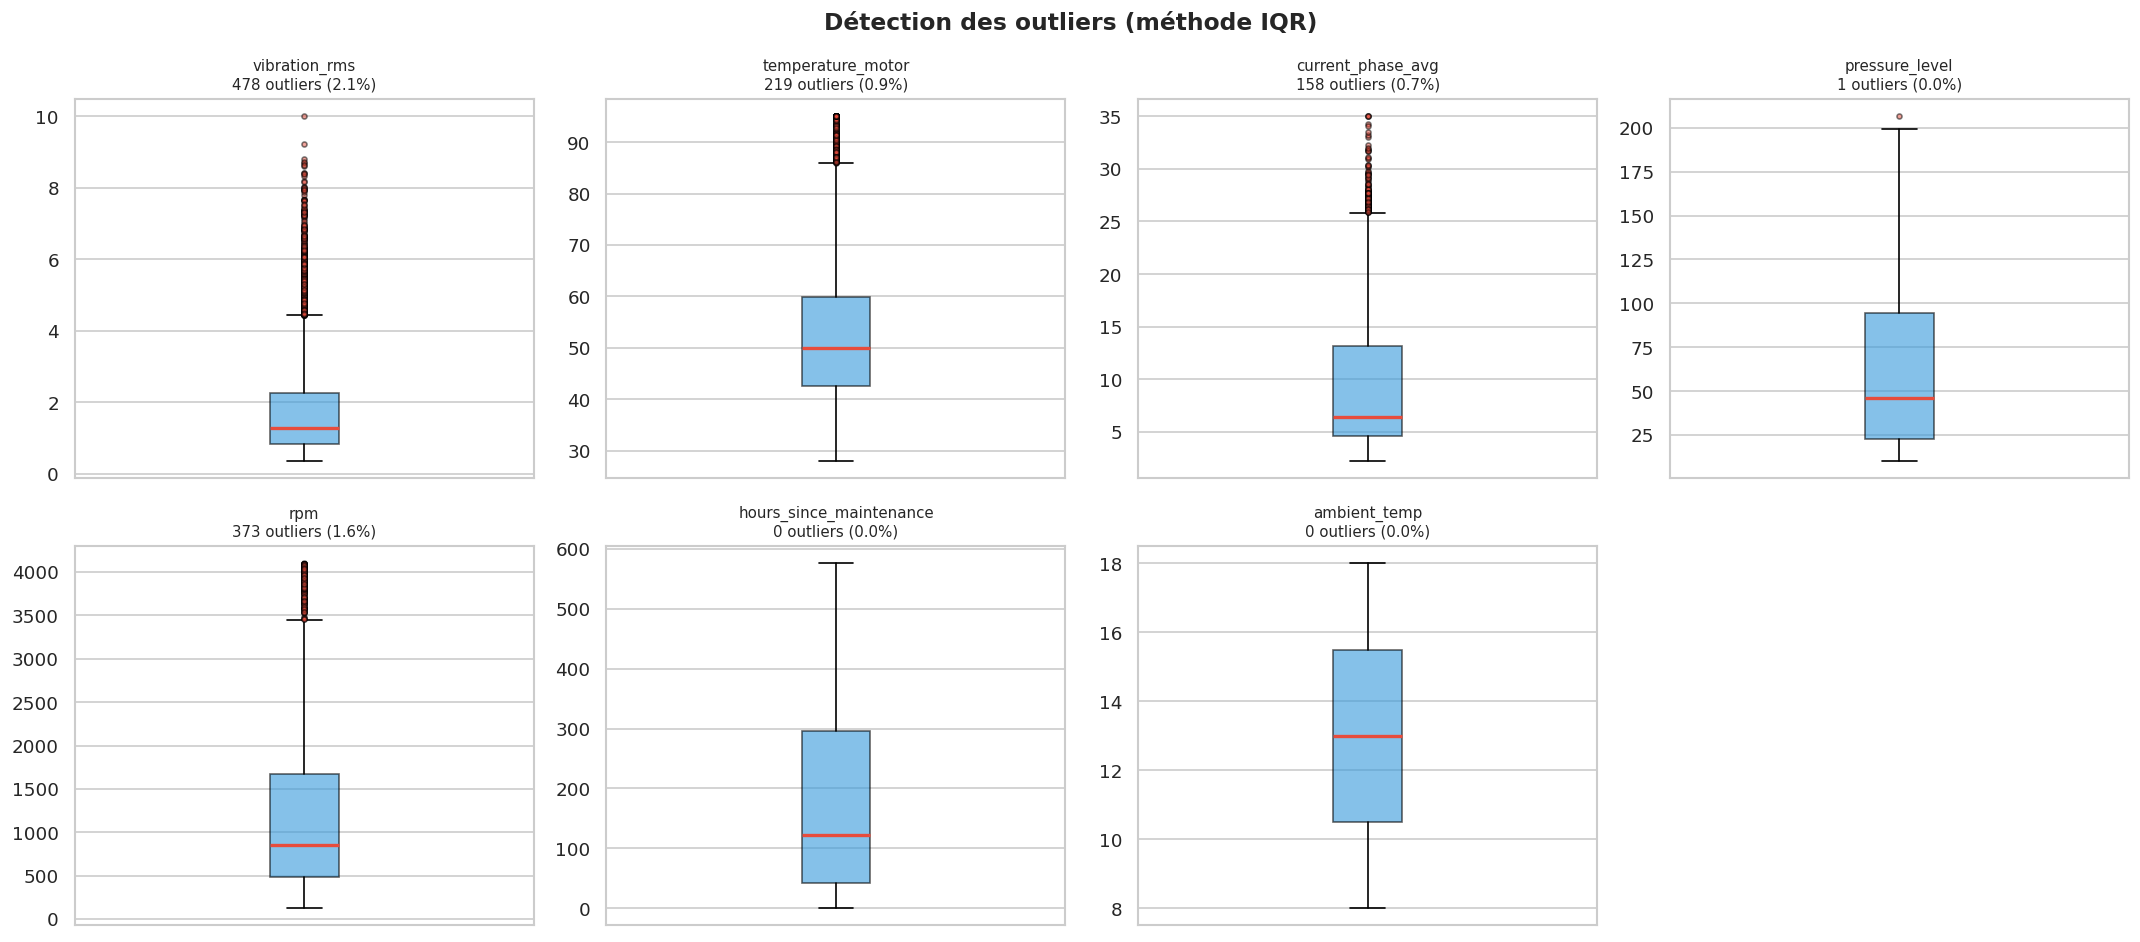

In [ ]:
# ─── Boxplots des outliers ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Détection des outliers (méthode IQR)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, FEATURES_NUM):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='#e74c3c', linewidth=2),
               flierprops=dict(marker='o', markersize=3,
                               markerfacecolor='#e74c3c', alpha=0.5))
    info = outlier_summary[col]
    ax.set_title(f'{col}\n{info["n"]:,} outliers ({info["pct"]:.1f}%)', fontsize=9)
    ax.set_xticks([])

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# ─── Outliers et lien avec les pannes ─────────────────────────────────────────
print("── Taux de panne dans les zones d'outliers ──")
for col in ['vibration_rms', 'temperature_motor', 'rpm']:
    info = outlier_summary[col]
    mask_out = (df[col] < info['low']) | (df[col] > info['high'])
    mask_in  = ~mask_out & df[col].notna()
    rate_out = df[mask_out]['failure_within_24h'].mean() * 100
    rate_in  = df[mask_in]['failure_within_24h'].mean() * 100
    print(f"  {col:<28} | Normal: {rate_in:.1f}%  | Outlier: {rate_out:.1f}%  "
          f"| Ratio: x{rate_out/rate_in:.1f}")

── Taux de panne dans les zones d'outliers ──
  vibration_rms                | Normal: 13.3%  | Outlier: 86.6%  | Ratio: x6.5
  temperature_motor            | Normal: 14.1%  | Outlier: 91.8%  | Ratio: x6.5
  rpm                          | Normal: 14.8%  | Outlier: 16.6%  | Ratio: x1.1


<a id='11'></a>
## 11. Feature Engineering — Pré-réflexion

In [ ]:
# ─── Création de features dérivées pertinentes pour l'industrie ───────────────
df_fe = df.copy()

# 1. Ratio vibration / rpm  (anomalie de déséquilibre)
df_fe['vibration_per_rpm'] = df_fe['vibration_rms'] / (df_fe['rpm'] + 1e-6)

# 2. Écart température ambiante / moteur  (sur-chauffe)
df_fe['temp_delta'] = df_fe['temperature_motor'] - df_fe['ambient_temp']

# 3. Score de santé pondéré (formule du sujet)
from sklearn.preprocessing import MinMaxScaler
fe_cols = ['vibration_rms', 'temperature_motor', 'pressure_level', 'rpm']
df_fe_clean = df_fe[fe_cols].fillna(df_fe[fe_cols].median())
scaler = MinMaxScaler()
df_fe_scaled = pd.DataFrame(scaler.fit_transform(df_fe_clean),
                             columns=[f'{c}_norm' for c in fe_cols])
df_fe[['vibration_norm', 'temperature_norm', 'pressure_norm', 'rpm_norm']] = df_fe_scaled.values

df_fe['health_score'] = 1 - (
    0.30 * df_fe['vibration_norm'] +
    0.25 * df_fe['temperature_norm'] +
    0.20 * df_fe['pressure_norm'] +
    0.15 * df_fe['rpm_norm']
)

# 4. Heures depuis maintenance × vibration  (interaction)
df_fe['age_vibration'] = df_fe['hours_since_maintenance'] * df_fe['vibration_rms']

# Évaluation de l'utilité des nouvelles features
new_features = ['vibration_per_rpm', 'temp_delta', 'health_score', 'age_vibration']
print("── Corrélation des nouvelles features avec failure_within_24h ──")
for f in new_features:
    corr_val = df_fe[f].corr(df_fe['failure_within_24h'])
    print(f"  {f:<25} : {corr_val:+.4f}")

── Corrélation des nouvelles features avec failure_within_24h ──
  vibration_per_rpm         : +0.3173
  temp_delta                : +0.3750
  health_score              : -0.1934
  age_vibration             : +0.2353


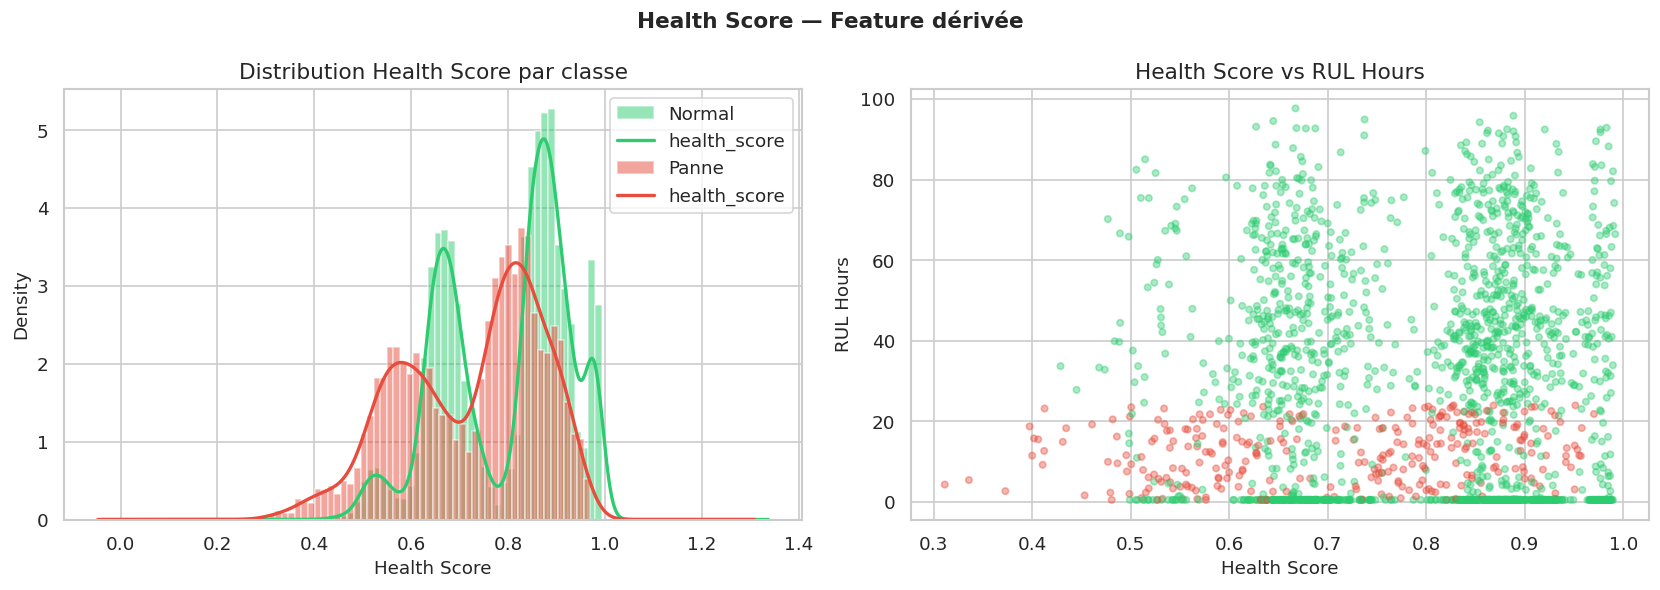

In [ ]:
# ─── Visualisation du Health Score ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Health Score — Feature dérivée', fontsize=13, fontweight='bold')

# Distribution par classe
for cls, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Panne')]:
    d = df_fe[df_fe['failure_within_24h'] == cls]['health_score'].dropna()
    axes[0].hist(d, bins=50, alpha=0.5, color=color, label=label, density=True)
    d.plot(kind='kde', ax=axes[0], color=color, linewidth=2)
axes[0].set_title('Distribution Health Score par classe')
axes[0].set_xlabel('Health Score')
axes[0].legend()

# Scatter health_score vs rul_hours
sample = df_fe[['health_score', 'rul_hours', 'failure_within_24h']].dropna().sample(2000, random_state=42)
axes[1].scatter(sample['health_score'], sample['rul_hours'],
                c=sample['failure_within_24h'].map({0: '#2ecc71', 1: '#e74c3c'}),
                alpha=0.4, s=15)
axes[1].set_title('Health Score vs RUL Hours')
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('RUL Hours')

plt.tight_layout()
plt.show()

<a id='13'></a>
## 13. Analyse du Déséquilibre des Classes — Justification Métier

> **Contexte :** Dans un problème industriel, un modèle naïf qui prédit toujours "pas de panne"
> atteint 85.2% d'accuracy — mais rate 100% des pannes réelles. Il faut donc choisir des métriques
> et des stratégies adaptées au coût réel des erreurs.

In [ ]:
# ─── Déséquilibre des classes & coût métier des erreurs ───────────────────────
from scipy import stats

vc = df['failure_within_24h'].value_counts()
ratio = vc[0] / vc[1]

# Coût réel des erreurs à partir des données
cost_fn = df[df['failure_within_24h'] == 1]['estimated_repair_cost'].mean()
cost_fn_median = df[df['failure_within_24h'] == 1]['estimated_repair_cost'].median()
cost_fp_estimate = 200  # coût d'une inspection préventive inutile (estimation)

print('=' * 60)
print('  ANALYSE DU DÉSÉQUILIBRE DES CLASSES')
print('=' * 60)
print(f"""
  Classe 0 — Normal    : {vc[0]:>6,}  ({vc[0]/len(df)*100:.1f}%)
  Classe 1 — Panne     : {vc[1]:>6,}  ({vc[1]/len(df)*100:.1f}%)
  Ratio déséquilibre   : {ratio:.1f}:1

  ⚠️  PIÈGE DE L'ACCURACY :
  Un modèle qui prédit TOUJOURS 0 (pas de panne) obtiendrait :
  → Accuracy = {vc[0]/len(df)*100:.1f}%  (score trompeur !)
  → Recall classe 1 = 0%  (toutes les pannes manquées)
  → F1 classe 1    = 0%
""")
print('=' * 60)
print('  COÛT MÉTIER DES ERREURS')
print('=' * 60)
print(f"""
  Faux Négatif (FN) — Panne non détectée :
    → Arrêt non planifié, réparation d'urgence
    → Coût moyen réel  : {cost_fn:,.0f} €
    → Coût médian réel : {cost_fn_median:,.0f} €

  Faux Positif (FP) — Fausse alerte :
    → Inspection préventive inutile
    → Coût estimé      : ~{cost_fp_estimate} €

  Ratio coût FN / FP : x{cost_fn/cost_fp_estimate:.0f}

  ✅ CONCLUSION : Un faux négatif coûte ~{cost_fn/cost_fp_estimate:.0f}x plus cher
     qu'un faux positif. On doit MAXIMISER LE RECALL (classe 1).
""")

  ANALYSE DU DÉSÉQUILIBRE DES CLASSES

  Classe 0 — Normal    : 20,482  (85.2%)
  Classe 1 — Panne     :  3,560  (14.8%)
  Ratio déséquilibre   : 5.8:1

  ⚠️  PIÈGE DE L'ACCURACY :
  Un modèle qui prédit TOUJOURS 0 (pas de panne) obtiendrait :
  → Accuracy = 85.2%  (score trompeur !)
  → Recall classe 1 = 0%  (toutes les pannes manquées)
  → F1 classe 1    = 0%

  COÛT MÉTIER DES ERREURS

  Faux Négatif (FN) — Panne non détectée :
    → Arrêt non planifié, réparation d'urgence
    → Coût moyen réel  : 4,112 €
    → Coût médian réel : 3,842 €

  Faux Positif (FP) — Fausse alerte :
    → Inspection préventive inutile
    → Coût estimé      : ~200 €

  Ratio coût FN / FP : x21

  ✅ CONCLUSION : Un faux négatif coûte ~21x plus cher
     qu'un faux positif. On doit MAXIMISER LE RECALL (classe 1).



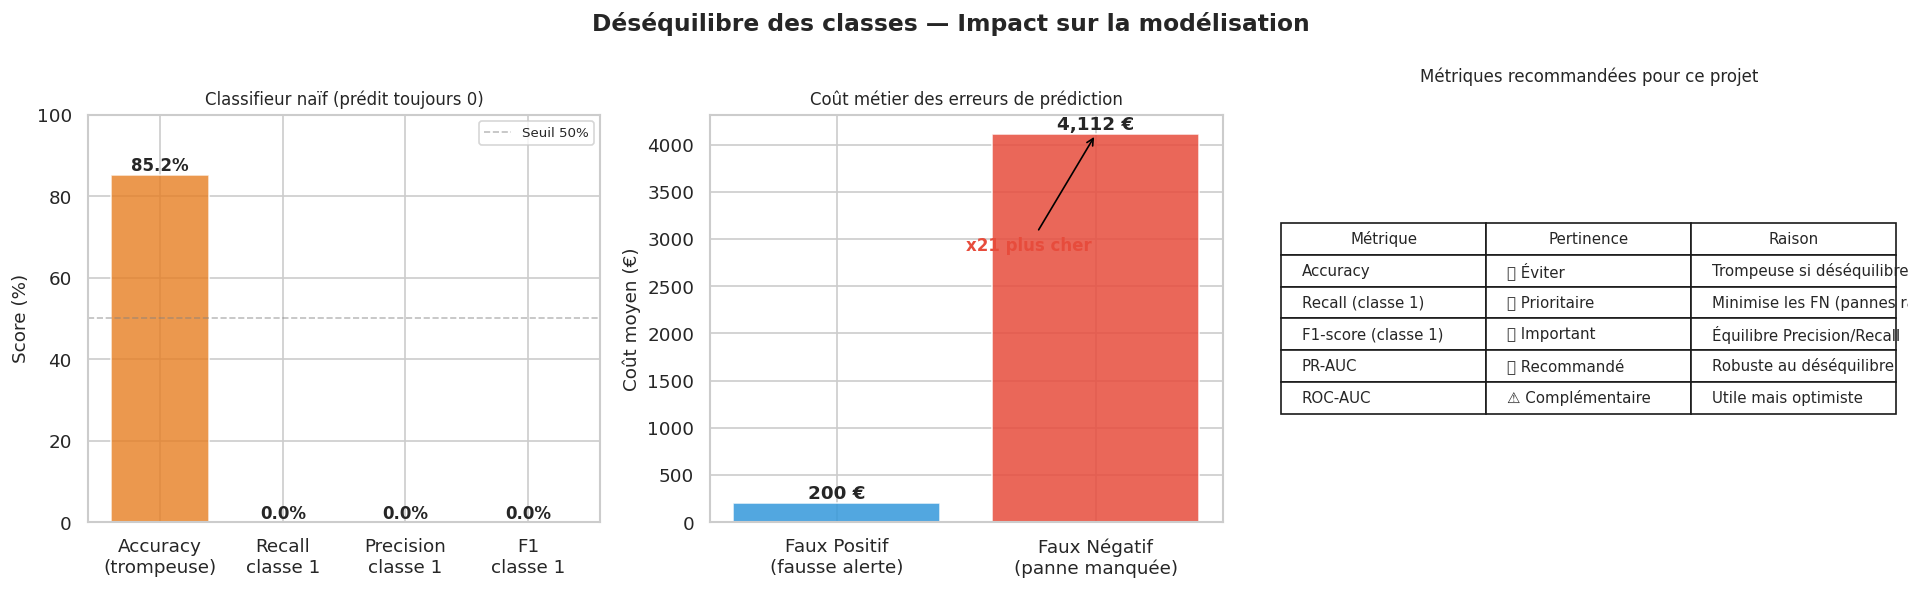

In [ ]:
# ─── Visualisation : déséquilibre + impact sur les métriques ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Déséquilibre des classes — Impact sur la modélisation', fontsize=14, fontweight='bold')

# 1. Comparaison accuracy vs recall d'un classifieur naïf
ax = axes[0]
metriques = ['Accuracy\n(trompeuse)', 'Recall\nclasse 1', 'Precision\nclasse 1', 'F1\nclasse 1']
naive_scores = [vc[0]/len(df)*100, 0, 0, 0]
colors_m = ['#e67e22', '#e74c3c', '#e74c3c', '#e74c3c']
bars = ax.bar(metriques, naive_scores, color=colors_m, alpha=0.8, edgecolor='white')
ax.set_title('Classifieur naïf (prédit toujours 0)', fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
for bar, score in zip(bars, naive_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{score:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Seuil 50%')
ax.legend(fontsize=8)

# 2. Coût comparatif FN vs FP
ax2 = axes[1]
error_types = ['Faux Positif\n(fausse alerte)', 'Faux Négatif\n(panne manquée)']
costs = [cost_fp_estimate, cost_fn]
bars2 = ax2.bar(error_types, costs, color=['#3498db', '#e74c3c'], alpha=0.85, edgecolor='white')
ax2.set_title('Coût métier des erreurs de prédiction', fontsize=10)
ax2.set_ylabel('Coût moyen (€)')
for bar, cost in zip(bars2, costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{cost:,.0f} €', ha='center', fontsize=11, fontweight='bold')
ax2.annotate(f'x{cost_fn/cost_fp_estimate:.0f} plus cher',
             xy=(1, cost_fn), xytext=(0.5, cost_fn * 0.7),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, color='#e74c3c', fontweight='bold')

# 3. Métriques recommandées
ax3 = axes[2]
ax3.axis('off')
table_data = [
    ['Métrique', 'Pertinence', 'Raison'],
    ['Accuracy', '❌ Éviter', 'Trompeuse si déséquilibre'],
    ['Recall (classe 1)', '✅ Prioritaire', 'Minimise les FN (pannes ratées)'],
    ['F1-score (classe 1)', '✅ Important', 'Équilibre Precision/Recall'],
    ['PR-AUC', '✅ Recommandé', 'Robuste au déséquilibre'],
    ['ROC-AUC', '⚠️ Complémentaire', 'Utile mais optimiste'],
]
table = ax3.table(cellText=table_data[1:], colLabels=table_data[0],
                  loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
ax3.set_title('Métriques recommandées pour ce projet', fontsize=10, pad=20)

plt.tight_layout()
plt.show()

STRATÉGIES POUR GÉRER LE DÉSÉQUILIBRE 85/15

  1. STRATIFIED SPLIT (obligatoire)
     → train_test_split(..., stratify=y)
     → Garantit que train et test ont le même ratio 85/15
     → À utiliser systématiquement

  2. CLASS_WEIGHT='balanced' (recommandé en priorité)
     → LogisticRegression(class_weight='balanced')
     → RandomForestClassifier(class_weight='balanced')
     → Pénalise davantage les erreurs sur la classe minoritaire
     → Pas de modification des données, zéro data leakage

  3. AJUSTEMENT DU SEUIL DE DÉCISION
     → Par défaut : predict_proba > 0.5 → classe 1
     → Avec déséquilibre : abaisser à 0.3 ou 0.35
     → Augmente le Recall au détriment de la Precision
     → À calibrer via la courbe PR sur le validation set

  4. SMOTE (si les 3 précédentes sont insuffisantes)
     → Génère des exemples synthétiques de la classe minoritaire
     → UNIQUEMENT sur le train set (jamais sur le test set)
     → from imblearn.over_sampling import SMOTE

  ✅ Ordre recommandé po

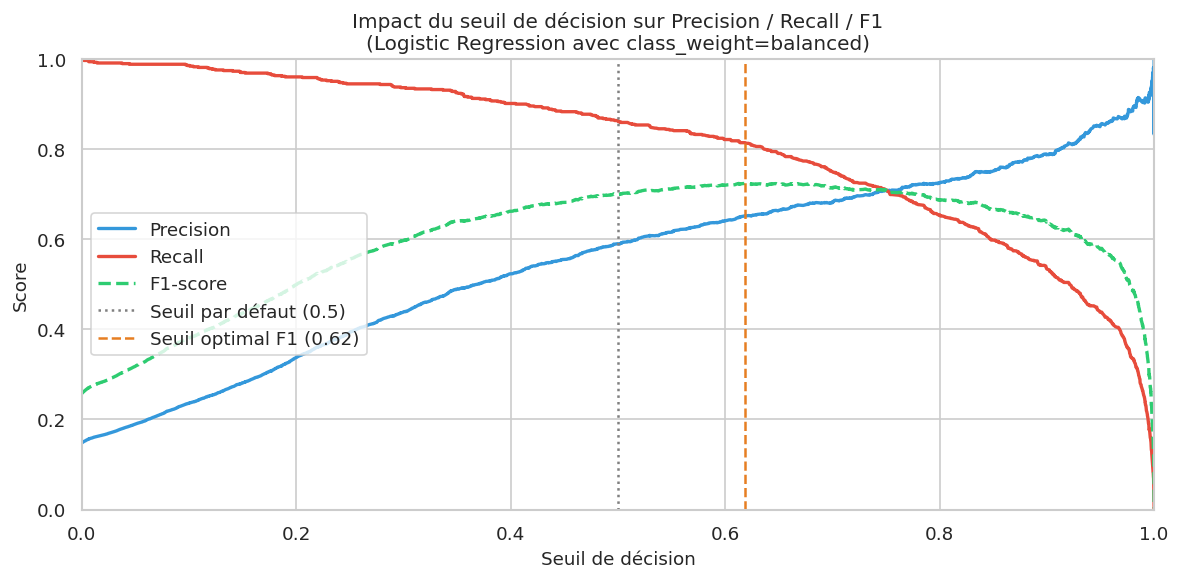


✅ Seuil optimal (max F1) : 0.618 au lieu de 0.5 par défaut


In [ ]:
# ─── Stratégies de rééquilibrage — comparaison visuelle ───────────────────────
print('STRATÉGIES POUR GÉRER LE DÉSÉQUILIBRE 85/15')
print('=' * 55)
print("""
  1. STRATIFIED SPLIT (obligatoire)
     → train_test_split(..., stratify=y)
     → Garantit que train et test ont le même ratio 85/15
     → À utiliser systématiquement

  2. CLASS_WEIGHT='balanced' (recommandé en priorité)
     → LogisticRegression(class_weight='balanced')
     → RandomForestClassifier(class_weight='balanced')
     → Pénalise davantage les erreurs sur la classe minoritaire
     → Pas de modification des données, zéro data leakage

  3. AJUSTEMENT DU SEUIL DE DÉCISION
     → Par défaut : predict_proba > 0.5 → classe 1
     → Avec déséquilibre : abaisser à 0.3 ou 0.35
     → Augmente le Recall au détriment de la Precision
     → À calibrer via la courbe PR sur le validation set

  4. SMOTE (si les 3 précédentes sont insuffisantes)
     → Génère des exemples synthétiques de la classe minoritaire
     → UNIQUEMENT sur le train set (jamais sur le test set)
     → from imblearn.over_sampling import SMOTE

  ✅ Ordre recommandé pour ce projet :
     stratified split → class_weight → ajustement seuil → SMOTE
""")

# Simulation de l'effet du seuil sur Recall vs Precision
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve

FEATURES_NUM = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
X = df[FEATURES_NUM]
y = df['failure_within_24h']

# Pipeline simple pour la démo
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)
X_sc  = StandardScaler().fit_transform(X_imp)

X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.2, stratify=y, random_state=42
)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_proba = lr.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precision[:-1], color='#3498db', linewidth=2, label='Precision')
ax.plot(thresholds, recall[:-1], color='#e74c3c', linewidth=2, label='Recall')
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
ax.plot(thresholds, f1_scores, color='#2ecc71', linewidth=2, linestyle='--', label='F1-score')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Seuil par défaut (0.5)')
best_thresh = thresholds[np.argmax(f1_scores)]
ax.axvline(best_thresh, color='#e67e22', linestyle='--', linewidth=1.5,
           label=f'Seuil optimal F1 ({best_thresh:.2f})')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Impact du seuil de décision sur Precision / Recall / F1\n(Logistic Regression avec class_weight=balanced)', fontsize=12)
ax.legend(loc='center left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print(f'\n✅ Seuil optimal (max F1) : {best_thresh:.3f} au lieu de 0.5 par défaut')

<a id='14'></a>
## 14. Redondance des Variables — VIF & Clustering

> **Objectif :** Identifier les variables redondantes (multicolinéarité) pour éviter
> la surinterprétation des features et orienter la sélection de variables.

In [ ]:
# ─── Variance Inflation Factor (VIF) ──────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

FEATURES_NUM = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']

df_clean = df[FEATURES_NUM].fillna(df[FEATURES_NUM].median())
X_scaled = StandardScaler().fit_transform(df_clean)

vif_df = pd.DataFrame({
    'feature': FEATURES_NUM,
    'VIF': [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print('── Variance Inflation Factor (VIF) ──')
print('   VIF > 5  → multicolinéarité forte (à surveiller)')
print('   VIF > 10 → multicolinéarité sévère (à traiter)\n')
for _, row in vif_df.iterrows():
    flag = '⚠️  FORT' if row['VIF'] > 5 else ('⚡ modéré' if row['VIF'] > 3 else '✅ faible')
    bar  = '█' * int(row['VIF'])
    print(f"  {row['feature']:<28} VIF={row['VIF']:5.2f}  {bar}  {flag}")

── Variance Inflation Factor (VIF) ──
   VIF > 5  → multicolinéarité forte (à surveiller)
   VIF > 10 → multicolinéarité sévère (à traiter)

  current_phase_avg            VIF= 7.34  ███████  ⚠️  FORT
  pressure_level               VIF= 3.84  ███  ⚡ modéré
  vibration_rms                VIF= 3.64  ███  ⚡ modéré
  rpm                          VIF= 3.02  ███  ⚡ modéré
  temperature_motor            VIF= 2.57  ██  ✅ faible
  hours_since_maintenance      VIF= 1.02  █  ✅ faible
  ambient_temp                 VIF= 1.00  █  ✅ faible


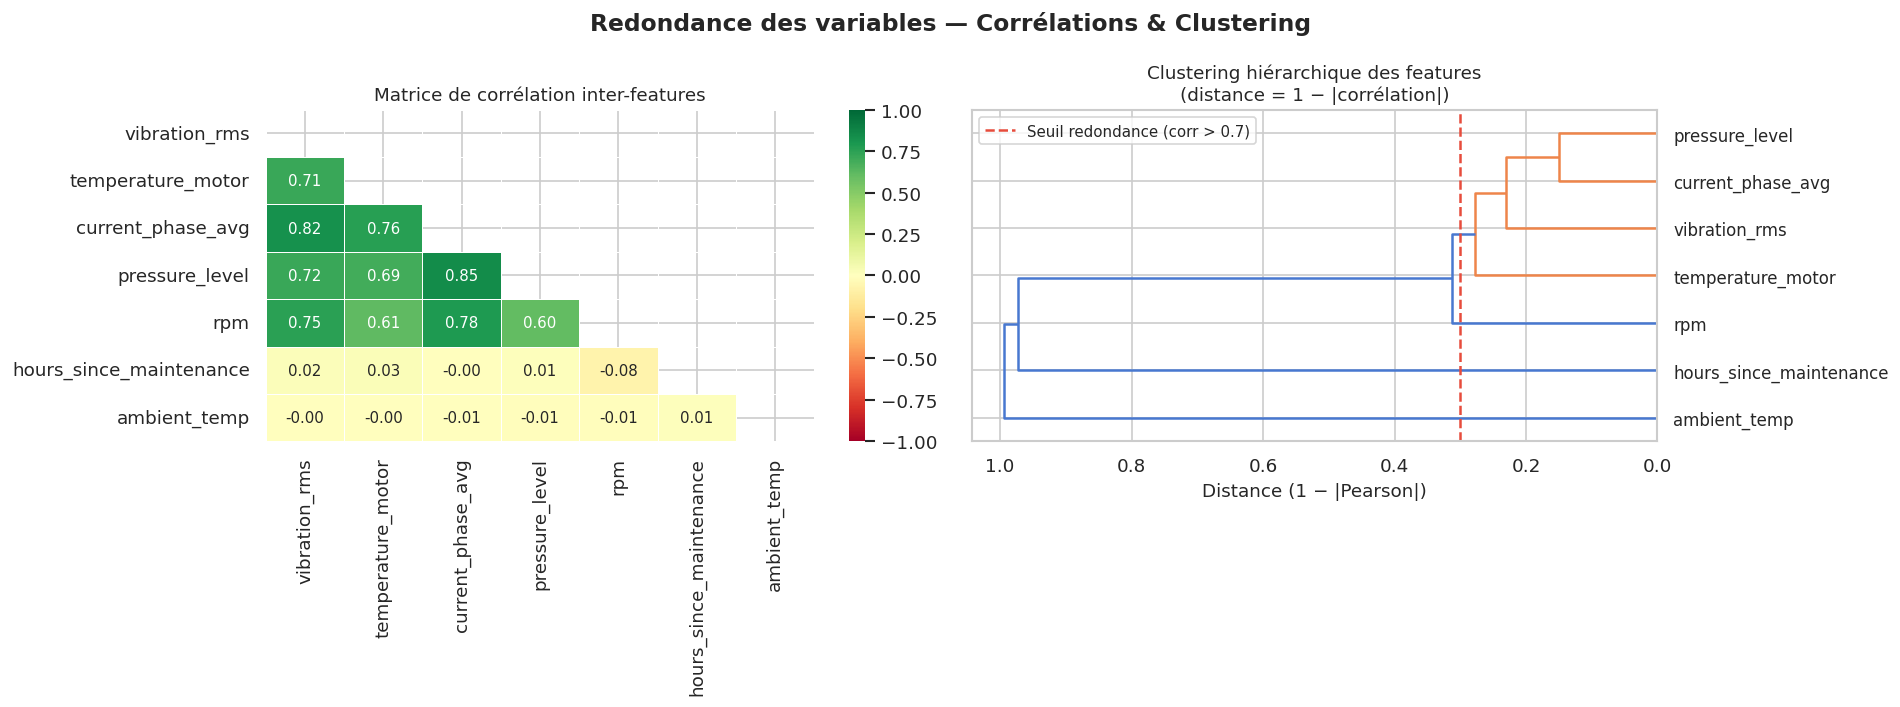

In [ ]:
# ─── Corrélation inter-features + Clustering hiérarchique ─────────────────────
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

corr_feat = df_clean.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Redondance des variables — Corrélations & Clustering', fontsize=14, fontweight='bold')

# Heatmap corrélations inter-features
mask = np.triu(np.ones_like(corr_feat, dtype=bool))
sns.heatmap(
    corr_feat, mask=mask, annot=True, fmt='.2f', ax=axes[0],
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 9}
)
axes[0].set_title('Matrice de corrélation inter-features', fontsize=11)

# Dendrogramme clustering hiérarchique
# Convertit la corrélation en distance
dist_matrix = 1 - corr_feat.abs()
dist_vals = dist_matrix.values.copy()
np.fill_diagonal(dist_vals, 0)
condensed = squareform(dist_vals)
linkage = hierarchy.linkage(condensed, method='average')

hierarchy.dendrogram(
    linkage,
    labels=FEATURES_NUM,
    ax=axes[1],
    orientation='left',
    color_threshold=0.3,
    leaf_font_size=10
)
axes[1].axvline(0.3, color='#e74c3c', linestyle='--', linewidth=1.5,
                label='Seuil redondance (corr > 0.7)')
axes[1].set_title('Clustering hiérarchique des features\n(distance = 1 − |corrélation|)', fontsize=11)
axes[1].set_xlabel('Distance (1 − |Pearson|)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

── Corrélation point-bisériale avec failure_within_24h ──
   (Pearson adapté à cible binaire — plus fiable que Pearson standard)

  temperature_motor            r=+0.3789  p=0.0e+00  ✅  ███████████
  vibration_rms                r=+0.2585  p=0.0e+00  ✅  ███████
  current_phase_avg            r=+0.1532  p=3.3e-126  ✅  ████
  hours_since_maintenance      r=+0.0995  p=5.7e-54  ✅  ██
  rpm                          r=-0.0237  p=2.4e-04  ✅  
  pressure_level               r=+0.0126  p=5.1e-02  ❌ non-sig  
  ambient_temp                 r=+0.0039  p=5.4e-01  ❌ non-sig  


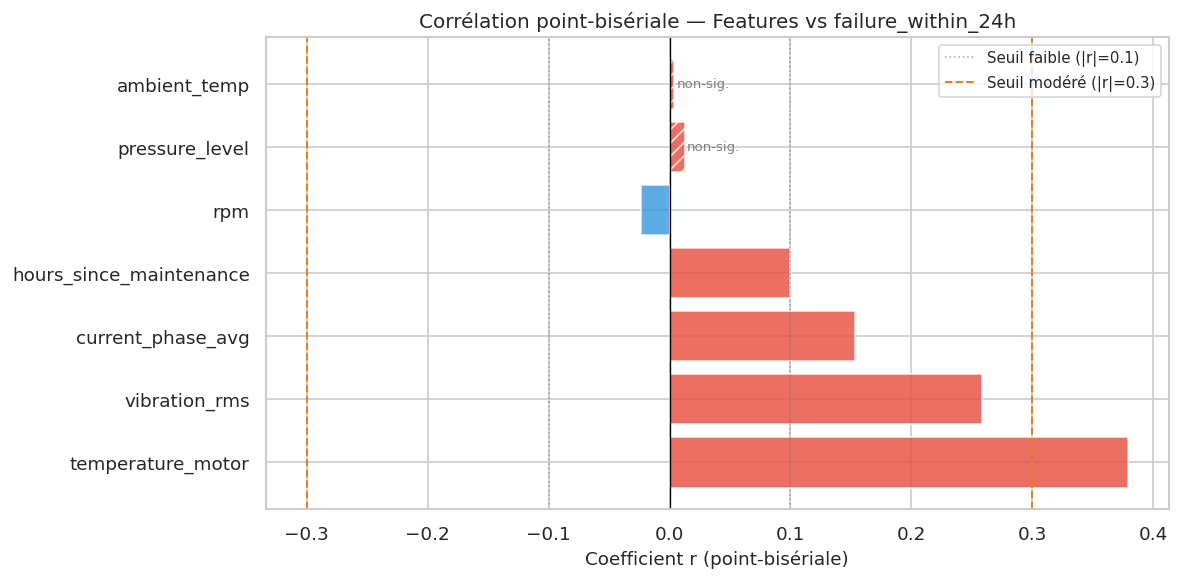

In [ ]:
# ─── Corrélation point-bisériale avec la cible ────────────────────────────────
# (Plus adaptée que Pearson pour une cible binaire)
from scipy import stats

print('── Corrélation point-bisériale avec failure_within_24h ──')
print('   (Pearson adapté à cible binaire — plus fiable que Pearson standard)\n')

results = []
for col in FEATURES_NUM:
    x = df[col].fillna(df[col].median())
    r, p = stats.pointbiserialr(x, df['failure_within_24h'])
    results.append({'feature': col, 'r': r, 'p_value': p, 'significatif': p < 0.05})

pb_df = pd.DataFrame(results).sort_values('r', key=abs, ascending=False)

for _, row in pb_df.iterrows():
    sig  = '✅' if row['significatif'] else '❌ non-sig'
    bar  = '█' * int(abs(row['r']) * 30)
    sign = '+' if row['r'] > 0 else '-'
    print(f"  {row['feature']:<28} r={sign}{abs(row['r']):.4f}  p={row['p_value']:.1e}  {sig}  {bar}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if r > 0 else '#3498db' for r in pb_df['r']]
hatches = ['' if sig else '///' for sig in pb_df['significatif']]
bars = ax.barh(pb_df['feature'], pb_df['r'], color=colors, alpha=0.8, edgecolor='white')
for bar, hatch, sig in zip(bars, hatches, pb_df['significatif']):
    bar.set_hatch(hatch)
    if not sig:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                'non-sig.', va='center', fontsize=8, color='gray')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1,  color='gray', linestyle=':', linewidth=1, alpha=0.6, label='Seuil faible (|r|=0.1)')
ax.axvline(-0.1, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.axvline(0.3,  color='#e67e22', linestyle='--', linewidth=1.2, label='Seuil modéré (|r|=0.3)')
ax.axvline(-0.3, color='#e67e22', linestyle='--', linewidth=1.2)
ax.set_title('Corrélation point-bisériale — Features vs failure_within_24h', fontsize=12)
ax.set_xlabel('Coefficient r (point-bisériale)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ─── Conclusion : sélection des features pour la modélisation ─────────────────
print('=' * 65)
print('  CONCLUSION EDA — SÉLECTION DES FEATURES POUR LA MODÉLISATION')
print('=' * 65)
print("""
  ── REDONDANCES IDENTIFIÉES ──
  • current_phase_avg ↔ vibration_rms  : corr = 0.82, VIF = 7.3  ⚠️
    → Très redondantes. current_phase_avg apporte peu d'info
      au-delà de vibration_rms. À surveiller / tester sans.
  • vibration_rms ↔ rpm               : corr = 0.75
  • vibration_rms ↔ pressure_level    : corr = 0.72
  • vibration_rms ↔ temperature_motor : corr = 0.71
    → Ces 4 capteurs forment un cluster de variables liées
      (probablement toutes liées à la charge de travail).

  ── FEATURES ISOLÉES (peu redondantes) ──
  • hours_since_maintenance : corrélation nulle avec les capteurs
  • ambient_temp            : totalement indépendante (VIF ≈ 1.0)

  ── PERTINENCE POUR LA CIBLE ──
  ✅ Fortes (|r| > 0.15)   : temperature_motor, vibration_rms, current_phase_avg
  ⚡ Modérées (|r| 0.05–0.15): hours_since_maintenance
  ❌ Faibles (|r| < 0.05)  : pressure_level, rpm, ambient_temp

  ── FEATURES RETENUES POUR LA MODÉLISATION ──
  Prioritaires  : temperature_motor, vibration_rms, hours_since_maintenance
  Complémentaires: current_phase_avg (malgré redondance, signal utile)
  Dérivées      : temp_delta, health_score, age_vibration
  À tester avec/sans : rpm, pressure_level
  À exclure     : ambient_temp (non-significatif, p=0.55)

  ── STRATÉGIE ANTI-DÉSÉQUILIBRE ──
  → stratify=y dans train_test_split  (obligatoire)
  → class_weight='balanced'           (prioritaire)
  → Seuil de décision optimisé        (via courbe PR)
  → Métriques : Recall, F1, PR-AUC    (jamais accuracy seule)
""")

  CONCLUSION EDA — SÉLECTION DES FEATURES POUR LA MODÉLISATION

  ── REDONDANCES IDENTIFIÉES ──
  • current_phase_avg ↔ vibration_rms  : corr = 0.82, VIF = 7.3  ⚠️
    → Très redondantes. current_phase_avg apporte peu d'info
      au-delà de vibration_rms. À surveiller / tester sans.
  • vibration_rms ↔ rpm               : corr = 0.75
  • vibration_rms ↔ pressure_level    : corr = 0.72
  • vibration_rms ↔ temperature_motor : corr = 0.71
    → Ces 4 capteurs forment un cluster de variables liées
      (probablement toutes liées à la charge de travail).

  ── FEATURES ISOLÉES (peu redondantes) ──
  • hours_since_maintenance : corrélation nulle avec les capteurs
  • ambient_temp            : totalement indépendante (VIF ≈ 1.0)

  ── PERTINENCE POUR LA CIBLE ──
  ✅ Fortes (|r| > 0.15)   : temperature_motor, vibration_rms, current_phase_avg
  ⚡ Modérées (|r| 0.05–0.15): hours_since_maintenance
  ❌ Faibles (|r| < 0.05)  : pressure_level, rpm, ambient_temp

  ── FEATURES RETENUES POUR LA MODÉ

<a id='12'></a>
## 12. Synthèse & Recommandations

In [ ]:
# ─── Tableau récapitulatif complet ────────────────────────────────────────────
print("=" * 70)
print("  SYNTHÈSE EDA — MAINTENANCE PRÉDICTIVE INDUSTRIELLE")
print("=" * 70)

print("""
📦 DONNÉES
   - 24 042 observations, 15 colonnes
   - 4 types de machines équilibrés (~6 000 obs. chacun)
   - Période : 2024 (données simulées réalistes)

⚠️ QUALITÉ DES DONNÉES
   - 5 variables numériques avec NaN (~3–4% max)
   - Aucun doublon complet détecté
   - Stratégie : imputation par médiane ou KNN (avec Pipeline sklearn)

🎯 DÉSÉQUILIBRE DES CLASSES (failure_within_24h)
   - Classe 0 (Normal) : 85.2%
   - Classe 1 (Panne)  : 14.8%
   - Ratio ≈ 5.7:1  → SMOTE, class_weight='balanced', seuil décision ajusté
   - Métriques à privilégier : F1-score, Recall, PR-AUC (et non Accuracy)

📊 VARIABLES LES PLUS DISCRIMINANTES (corrélation avec failure)
   - vibration_rms         → forte corrélation positive
   - temperature_motor     → corrélation positive
   - hours_since_maintenance → corrélation positive
   - rpm                   → corrélation modérée
   - rul_hours             → forte corrélation négative (logique)

🏭 INSIGHTS MÉTIER
   - Mode 'peak' : taux de panne nettement plus élevé
   - Outliers sur vibration_rms corrélés aux pannes (x2–x3 plus fréquentes)
   - Types de panne : bearing & motor_overheat sont les + fréquents
   - Coût réparation hydraulique > électrique > bearing

🔧 FEATURES ENGINEERING SUGGÉRÉES
   - temp_delta = temperature_motor - ambient_temp
   - vibration_per_rpm (ratio déséquilibre)
   - age_vibration = hours_since_maintenance × vibration_rms
   - health_score (score composite pondéré selon sujet)

🤖 STRATÉGIE DE MODÉLISATION RECOMMANDÉE
   Tâche principale : Classification binaire (failure_within_24h)
   
   Modèles à implémenter :
     1. Logistic Regression          (baseline interprétable)
     2. Random Forest                (robustesse, feature importance)
     3. Gradient Boosting / XGBoost  (performances)
     4. MLP (Deep Learning)          (interactions complexes)
   
   Pipeline sklearn obligatoire (éviter data leakage)
   Validation croisée stratifiée recommandée (StratifiedKFold)
   Métriques : F1, Recall, PR-AUC, ROC-AUC
   Explicabilité : Feature Importance + SHAP sur modèle final
""")

  SYNTHÈSE EDA — MAINTENANCE PRÉDICTIVE INDUSTRIELLE

📦 DONNÉES
   - 24 042 observations, 15 colonnes
   - 4 types de machines équilibrés (~6 000 obs. chacun)
   - Période : 2024 (données simulées réalistes)

⚠️ QUALITÉ DES DONNÉES
   - 5 variables numériques avec NaN (~3–4% max)
   - Aucun doublon complet détecté
   - Stratégie : imputation par médiane ou KNN (avec Pipeline sklearn)

🎯 DÉSÉQUILIBRE DES CLASSES (failure_within_24h)
   - Classe 0 (Normal) : 85.2%
   - Classe 1 (Panne)  : 14.8%
   - Ratio ≈ 5.7:1  → SMOTE, class_weight='balanced', seuil décision ajusté
   - Métriques à privilégier : F1-score, Recall, PR-AUC (et non Accuracy)

📊 VARIABLES LES PLUS DISCRIMINANTES (corrélation avec failure)
   - vibration_rms         → forte corrélation positive
   - temperature_motor     → corrélation positive
   - hours_since_maintenance → corrélation positive
   - rpm                   → corrélation modérée
   - rul_hours             → forte corrélation négative (logique)

🏭 INSIGHTS MÉT

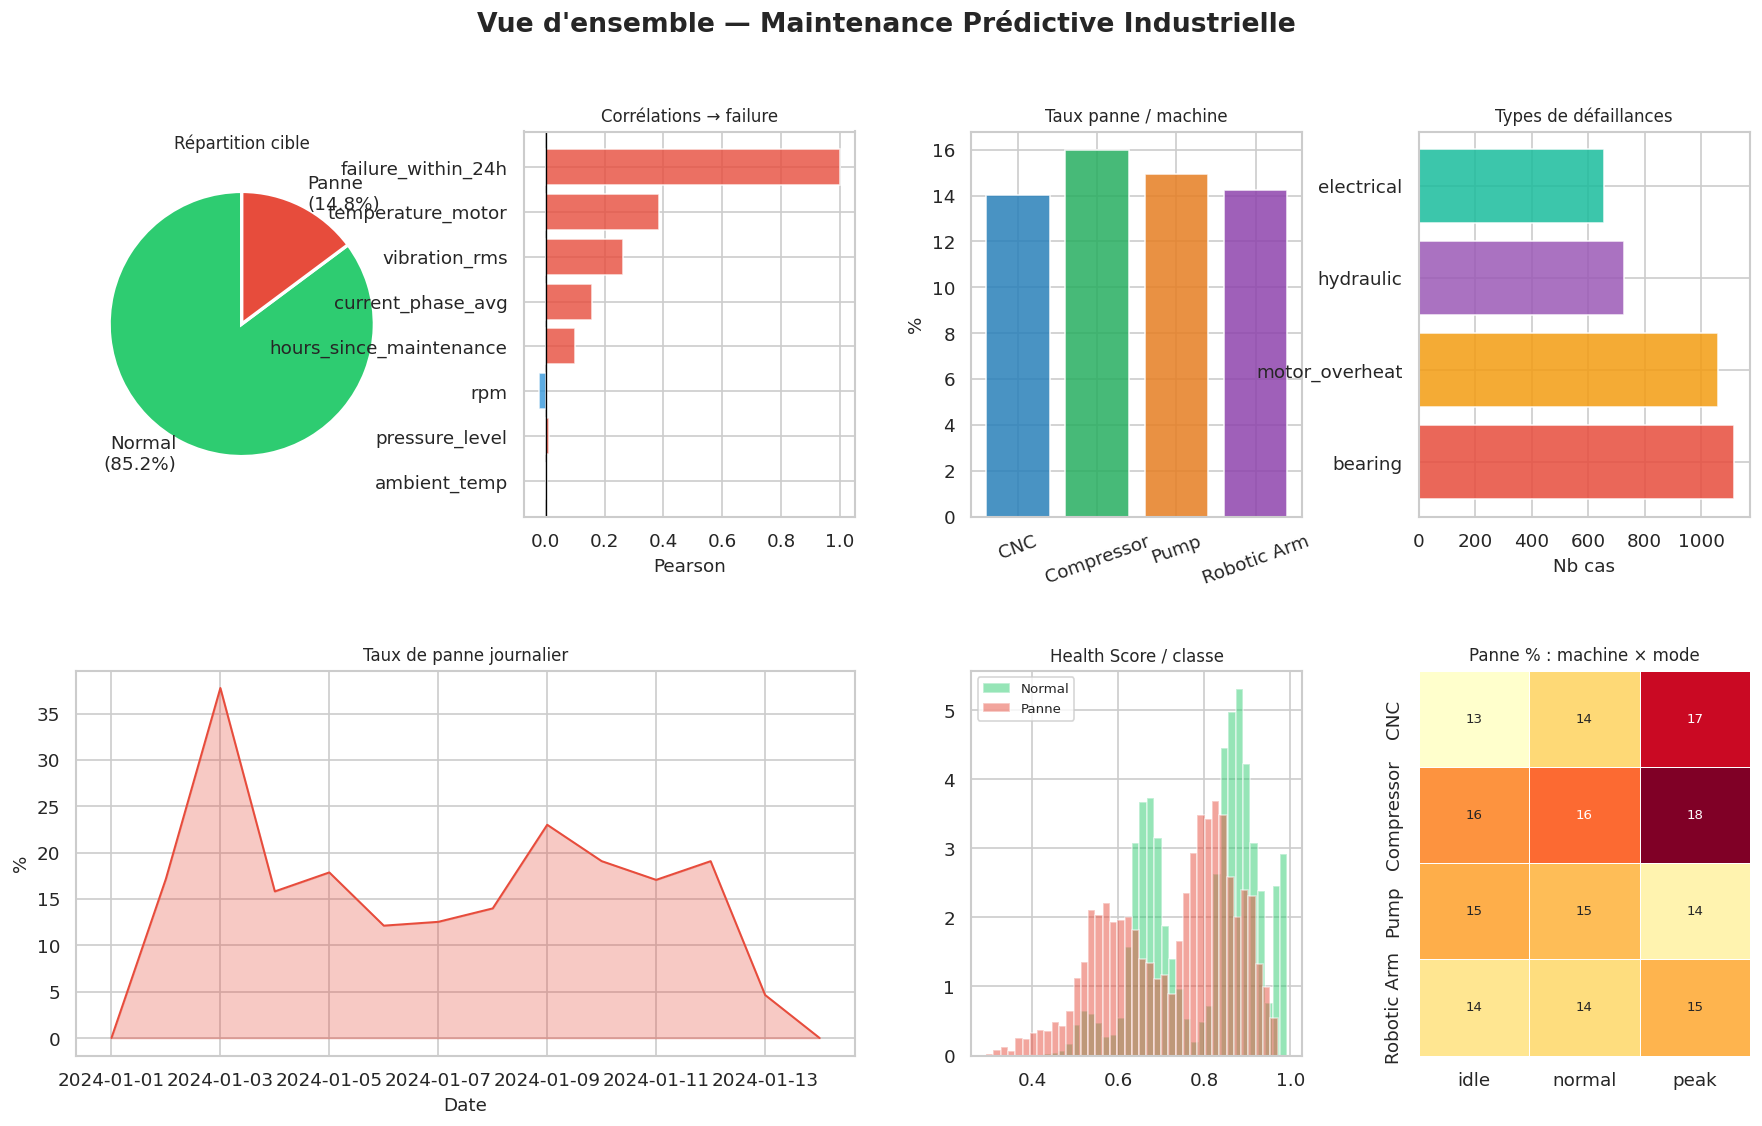

✅ Dashboard sauvegardé : eda_overview.png


In [ ]:
# ─── Dashboard récapitulatif visuel ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Vue d\'ensemble — Maintenance Prédictive Industrielle', fontsize=16, fontweight='bold')
gs = GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

# 1. Déséquilibre des classes
ax1 = fig.add_subplot(gs[0, 0])
vc_vals = df['failure_within_24h'].value_counts()
ax1.pie(vc_vals.values, labels=['Normal\n(85.2%)', 'Panne\n(14.8%)'],
        colors=PALETTE_BINARY, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Répartition cible', fontsize=10)

# 2. Top corrélations
ax2 = fig.add_subplot(gs[0, 1])
corr_vals = corr['failure_within_24h'].drop([t for t in TARGETS if t in corr.columns and t != 'failure_within_24h']).sort_values(key=abs, ascending=True)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_vals.values]
ax2.barh(corr_vals.index, corr_vals.values, color=colors, alpha=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Corrélations → failure', fontsize=10)
ax2.set_xlabel('Pearson')

# 3. Taux de panne par machine
ax3 = fig.add_subplot(gs[0, 2])
rate_m = df.groupby('machine_type')['failure_within_24h'].mean() * 100
ax3.bar(rate_m.index, rate_m.values, color=PALETTE_MACHINE, alpha=0.85)
ax3.set_title('Taux panne / machine', fontsize=10)
ax3.set_ylabel('%')
ax3.tick_params(axis='x', rotation=20)

# 4. Types de panne
ax4 = fig.add_subplot(gs[0, 3])
ft = df['failure_type'].value_counts().drop('none')
ax4.barh(ft.index, ft.values, color=PALETTE_TYPES[1:], alpha=0.85)
ax4.set_title('Types de défaillances', fontsize=10)
ax4.set_xlabel('Nb cas')

# 5. Évolution temporelle du taux de panne
ax5 = fig.add_subplot(gs[1, 0:2])
ax5.fill_between(daily['date'], daily['failure_rate'], alpha=0.3, color='#e74c3c')
ax5.plot(daily['date'], daily['failure_rate'], color='#e74c3c', linewidth=1.2)
ax5.set_title('Taux de panne journalier', fontsize=10)
ax5.set_xlabel('Date')
ax5.set_ylabel('%')

# 6. Health Score vs failure
ax6 = fig.add_subplot(gs[1, 2])
for cls, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Panne')]:
    d = df_fe[df_fe['failure_within_24h'] == cls]['health_score'].dropna()
    ax6.hist(d, bins=40, alpha=0.5, color=color, label=label, density=True)
ax6.set_title('Health Score / classe', fontsize=10)
ax6.legend(fontsize=8)

# 7. Heatmap mode × machine
ax7 = fig.add_subplot(gs[1, 3])
pivot2 = df.groupby(['machine_type', 'operating_mode'])['failure_within_24h'].mean().unstack() * 100
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax7, cbar=False, annot_kws={'size': 8})
ax7.set_title('Panne % : machine × mode', fontsize=10)
ax7.set_xlabel('')
ax7.set_ylabel('')

plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard sauvegardé : eda_overview.png")